In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfilt, welch

import h5py
import sys, os, glob
sys.path.append('../../')
import analysis_utils as utils
import calc_gas_collision_spectrum as calc_gas

from scipy.optimize import curve_fit as curve_fit

utils.load_plotting_setting()

In [2]:
import importlib
importlib.reload(utils)
importlib.reload(calc_gas)

<module 'calc_gas_collision_spectrum' from '/Users/yuhan/work/nanospheres/gas_collisions/analysis_notebooks/sphere_20260215_final_analysis/../../calc_gas_collision_spectrum.py'>

## Plot the calibration waveforms and integrate for amplitudes

In [42]:
def get_pulse_area(tt, dd):
    # Time in s, drive signal in V
    noise = np.mean(dd[tt < -0.5e-7])
    area = np.trapz(dd-noise, x=tt)
    
    return area

def process_pulse_waveforms(files):
    tt = None
    dds, aas = [], []
    for file in files:
        data = np.genfromtxt(file, delimiter=',', skip_header=1)
        _tt, _dd = data.T[0], data.T[1]
        _aa = get_pulse_area(_tt, _dd)

        if tt is None:
            tt = _tt

        dds.append(_dd)
        aas.append([_aa])

    return tt, dds, aas

# folder = r'E:\pulse_waveform\20241204_quantum_composers'
folder = r'/Volumes/LaCie/pulse_waveform/20241204_quantum_composers'

tt = None
dds_mean, dds_std, aas_mean, aas_std = [], [], [], []

for dataset in ['2_5v', '5v', '7_5v', '10v', '12_5v', '15v', '17_5v', '20v']:
    files = glob.glob(os.path.join(folder, f'{dataset}/C3_*.CSV'))
    _tt, dds, aas = process_pulse_waveforms(files)
    
    mean = np.mean(dds, axis=0)
    std = np.std(dds, axis=0)

    aa_mean = np.mean(aas)
    aa_std  = np.std(aas)

    if tt is None:
        tt = _tt

    dds_mean.append(mean)
    aas_mean.append(aa_mean)
    dds_std.append(std)
    aas_std.append(aa_std)

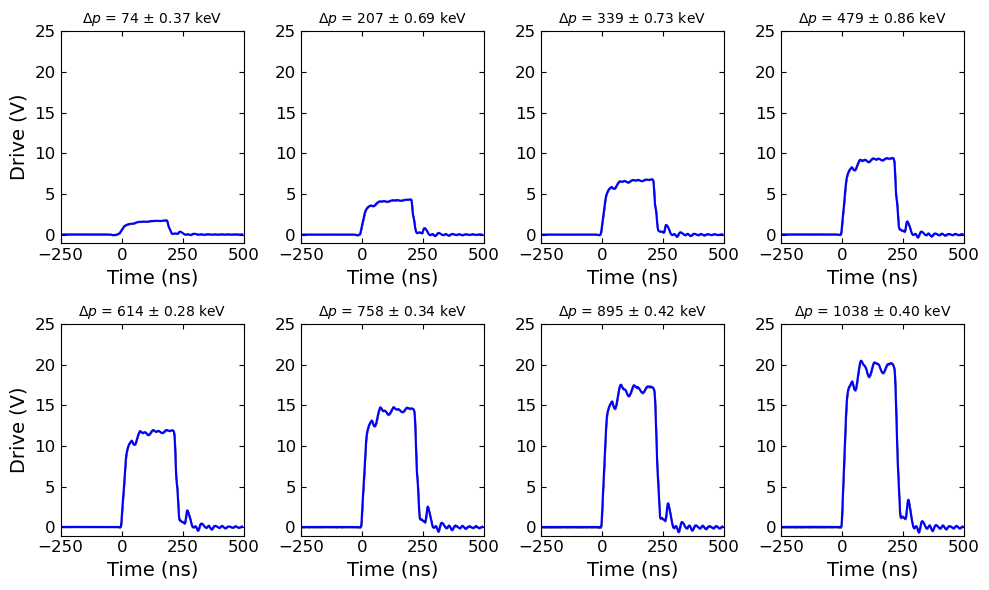

In [ ]:
charge = 6
efield = 137 # V/m

fig, axes = plt.subplots(2, 4, figsize=(10, 6))
for i in range(8):
    ax = axes.flatten()[i]

    amp_kev = charge * aas_mean[i] * efield * 1.602e-19 * utils.SI2ev / 1000
    amp_kev_std = charge * aas_std[i] * efield * 1.602e-19 * utils.SI2ev / 1000
    
    ax.fill_between(tt*1e9, dds_mean[i]-dds_std[i], dds_mean[i]+dds_std[i], color='grey', alpha=0.95)
    ax.plot(tt*1e9, dds_mean[i], color='blue')
    
    ax.set_title(fr'$\Delta p$ = {int(amp_kev)} $\pm$ {amp_kev_std:.2f} keV', fontsize=10)

    ax.set_xlim(-250, 500)
    ax.set_ylim(-1, 25)
    
    if i == 0 or i == 4:
        ax.set_ylabel('Drive (V)')

    ax.set_xlabel('Time (ns)')

fig.tight_layout()

## Read the processed calibration data

In [32]:
sphere = 'sphere_20260215'

def read_recon(dataset, voltages):
    file = rf'/Users/yuhan/work/nanospheres/gas_collisions/data_processed/pulse_calibration/{sphere}/{dataset}_processed.hdf5'

    amps_all, pulse_shapes_all, indices_in_win, zz_pulses_all, drive_area_all, f_res_all, noise_level_all = [], [], [], [], [], [], []
    f = h5py.File(file, 'r')
    for v in voltages:
        amps = f['data_processed'][f'amplitudes_{v}v'][:]
        ps = f['data_processed'][f'pulse_shapes_{v}v'][:]
        indices = f['data_processed'][f'pulse_indices_in_win_{v}v'][:]
        zz = f['data_processed'][f'z_signal_{v}v'][:]
        drive_area = f['data_processed'][f'drive_area_{v}v'][:]
        f_res = f['data_processed'][f'f_res_{v}v'][:]
        noise_level = f['data_processed'][f'noise_level_{v}v'][:]

        amps_all.append(amps)
        pulse_shapes_all.append(ps)
        indices_in_win.append(indices)
        zz_pulses_all.append(zz)
        drive_area_all.append(drive_area)
        f_res_all.append(f_res)
        noise_level_all.append(noise_level)

    try:
        amps_noise = f['data_processed'][f'amplitudes_noise_2.5v'][:]
        amps_noise_search = f['data_processed'][f'amplitudes_noise_search_2.5v'][:]
    except:
        amps_noise = None
        amps_noise_search = None

    f.close()

    return amps_all, amps_noise, amps_noise_search, pulse_shapes_all, indices_in_win, zz_pulses_all, drive_area_all, f_res_all, noise_level_all

In [44]:
dataset_0 = '20260219_p6e_4e-8mbar_d137khz_0'
dataset_1 = '20260219_p6e_4e-8mbar_d137khz_1_afterxe'
dataset_2 = '20260219_p6e_4e-8mbar_d137khz_2_afterkr'
dataset_3 = '20260219_p6e_4e-8mbar_d137khz_3_aftersf6'
datasets_all = [dataset_0, dataset_1, dataset_2, dataset_3]

voltages = [2.5, 5, 7.5, 10, 12.5, 15, 17.5, 20]

amps_all_0, amps_noise_0, amps_noise_search_0, pulse_shapes_all_0, indices_0, zz_pulses_all_0, drive_area_all_0, f_res_all_0, noise_level_all_0 = read_recon(dataset_0, voltages=voltages)
amps_all_1, amps_noise_1, amps_noise_search_1, pulse_shapes_all_1, indices_1, zz_pulses_all_1, drive_area_all_1, f_res_all_1, noise_level_all_1 = read_recon(dataset_1, voltages=voltages)
amps_all_2, amps_noise_2, amps_noise_search_2, pulse_shapes_all_2, indices_2, zz_pulses_all_2, drive_area_all_2, f_res_all_2, noise_level_all_2 = read_recon(dataset_2, voltages=voltages)
amps_all_3, amps_noise_3, amps_noise_search_3, pulse_shapes_all_3, indices_3, zz_pulses_all_3, drive_area_all_3, f_res_all_3, noise_level_all_3 = read_recon(dataset_3, voltages=voltages)

amp2keV 14245.798041390099
Fitted sigma: [47.82017436 76.88200181 46.40699101 58.78356927 50.66184514 57.57035509
 53.82821988 66.66020939] keV/c
Noise level 74.17308354570811 keV/c
amp2keV 14157.718831165625
Fitted sigma: [38.4135869  51.45041313 43.59110086 57.37606647 78.48694147 87.92050803
 90.79810158 64.23195397] keV/c
Noise level 44.95947849040576 keV/c
amp2keV 14516.20824074582
Fitted sigma: [37.57810204 38.87431696 46.75130773 44.67971369 51.18906006 52.824616
 49.22804093 52.93183162] keV/c
Noise level 43.990272373918906 keV/c
amp2keV 14402.03189575762
Fitted sigma: [40.05477058 48.67269584 38.20165132 47.16205705 41.30647036 67.54252004
 71.41198284 59.82735061] keV/c
Noise level 46.057177470842205 keV/c


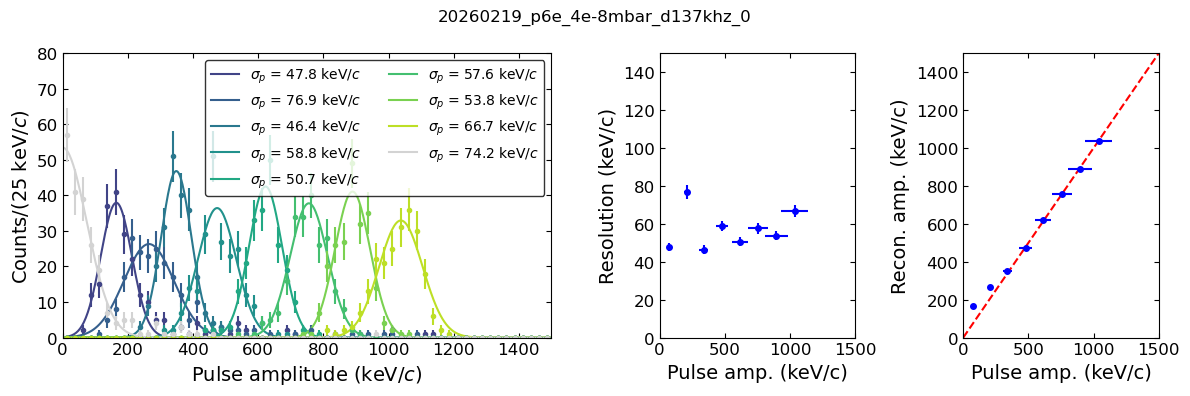

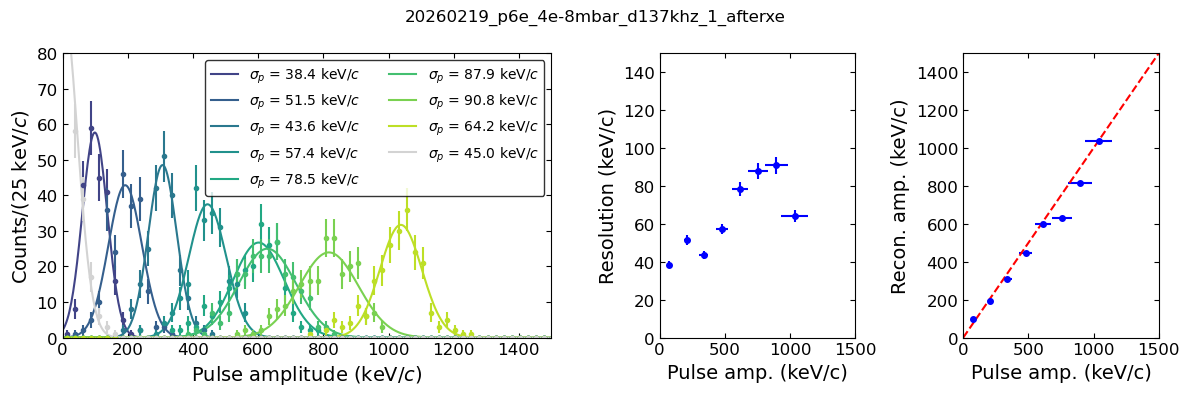

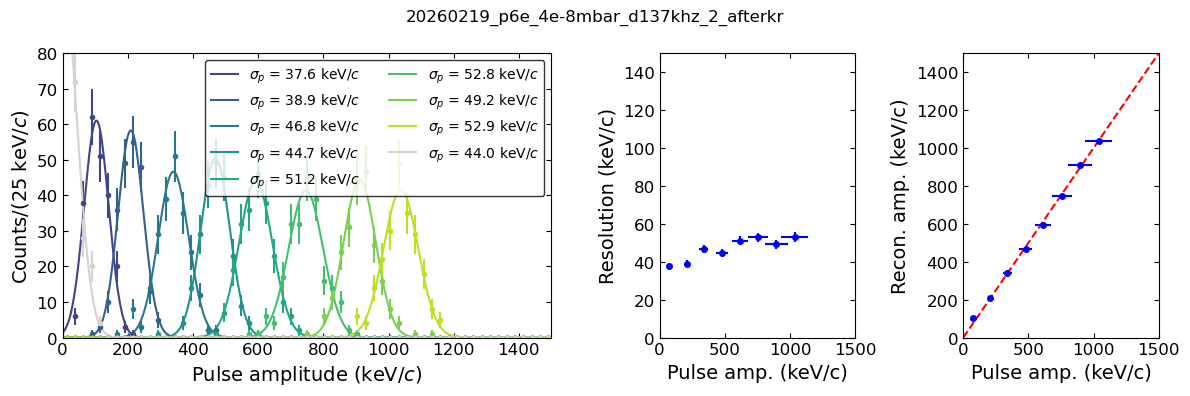

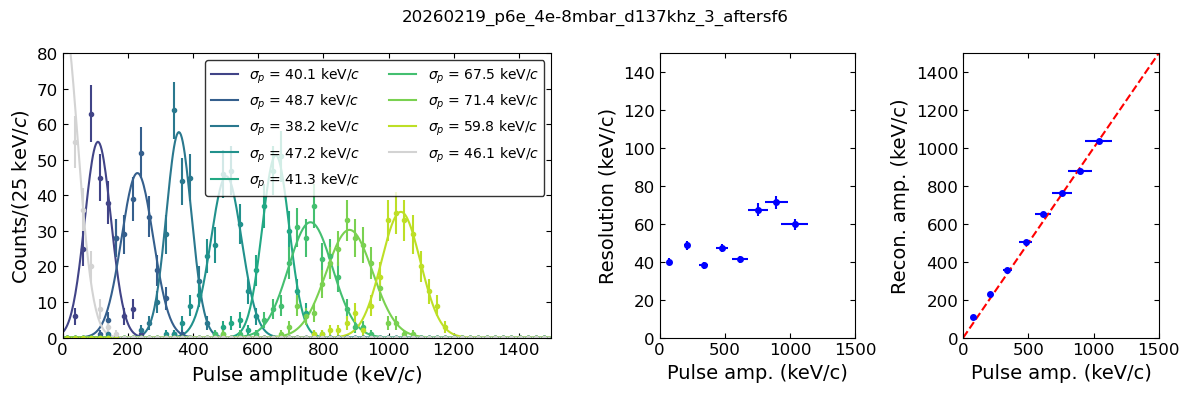

In [45]:
pulse_amp = np.asarray([74, 207, 339, 479, 614, 758, 895, 1038])
pulse_amp_err = pulse_amp * 0.10

amps_all = [amps_all_0, amps_all_1, amps_all_2, amps_all_3]
amps_noise_all = [amps_noise_0, amps_noise_1, amps_noise_2, amps_noise_3]

amp2kev_bin = 14250
for j in range(len(amps_all)):
    bins = np.arange(0, 3000, 25) / amp2kev_bin
    hhs, bcs, gps = utils.fit_amps_gaus(amps_all[j], bins=bins, noise=False, return_bins=False)

    amp2kevs = pulse_amp / np.asarray(gps).T[1]
    amp2kev = amp2kevs[-1]

    n_pulses = np.asarray([a.size for a in amps_all[j]])
    sigmas   = np.asarray(gps).T[2] * amp2kev   # resolution in keV/c
    means    = np.asarray(gps).T[1] * amp2kev   # recon amp in keV/c
    sigma_err = sigmas / np.sqrt(2 * (n_pulses - 1))  # std error of sample std dev
    mean_err  = sigmas / np.sqrt(n_pulses)             # std error of mean

    print('amp2keV', amp2kev)
    print('Fitted sigma:', sigmas, 'keV/c')

    xx = np.linspace(0, np.max(bcs[0]), 1000)
    fig, axes = plt.subplots(1, 3, figsize=(12, 4), width_ratios=[2.5, 1, 1])

    cmap = plt.colormaps.get_cmap('viridis')
    colors = cmap(np.linspace(0.2, 0.9, 8))
    for i in range(pulse_amp.size):
        axes[0].errorbar(bcs[i]*amp2kev, hhs[i], yerr=np.sqrt(hhs[i]), fmt='.', color=colors[i])
        axes[0].plot(xx*amp2kev, utils.gauss(xx, *gps[i]), label=fr'$\sigma_p$ = {gps[i][2]*amp2kev:.1f} keV/$c$', color=colors[i])

    try:
        hhs_noise, bcs_noise, gps_noise = utils.fit_amps_gaus([amps_noise_all[j]], bins=bins, noise=True, return_bins=False)
        axes[0].errorbar(bcs_noise[0]*amp2kev, hhs_noise[0], yerr=np.sqrt(hhs_noise[0]), fmt='.', color='lightgrey')
        axes[0].plot(xx*amp2kev, utils.gauss_zero(xx, *gps_noise[0]), label=fr'$\sigma_p$ = {gps_noise[0][1]*amp2kev:.1f} keV/$c$', color='lightgrey')
        print('Noise level', gps_noise[0][1]*amp2kev, 'keV/c')
    except:
        pass

    axes[0].set_xlim(0, 1500)
    axes[0].set_ylim(0, 80)
    axes[0].legend(edgecolor='k', ncol=2, fontsize=10)
    axes[0].set_xlabel(r'Pulse amplitude (keV/$c$)')
    axes[0].set_ylabel(r'Counts/(25 keV/$c$)')

    axes[1].errorbar(pulse_amp, sigmas, yerr=sigma_err, xerr=pulse_amp_err,
                     fmt='.', markersize=8, color='b')
    axes[1].set_xlim(0, 1500)
    axes[1].set_ylim(0, 150)
    axes[1].set_xlabel('Pulse amp. (keV/c)')
    axes[1].set_ylabel('Resolution (keV/c)')

    axes[2].errorbar(pulse_amp, means, yerr=mean_err, xerr=pulse_amp_err,
                     fmt='.', markersize=8, color='b')
    axes[2].plot(np.linspace(0, 1500, 50), np.linspace(0, 1500, 50), 'r--')
    axes[2].set_xlim(0, 1500)
    axes[2].set_ylim(0, 1500)
    axes[2].set_xlabel('Pulse amp. (keV/c)')
    axes[2].set_ylabel('Recon. amp. (keV/c)')

    fig.suptitle(datasets_all[j])
    fig.tight_layout()


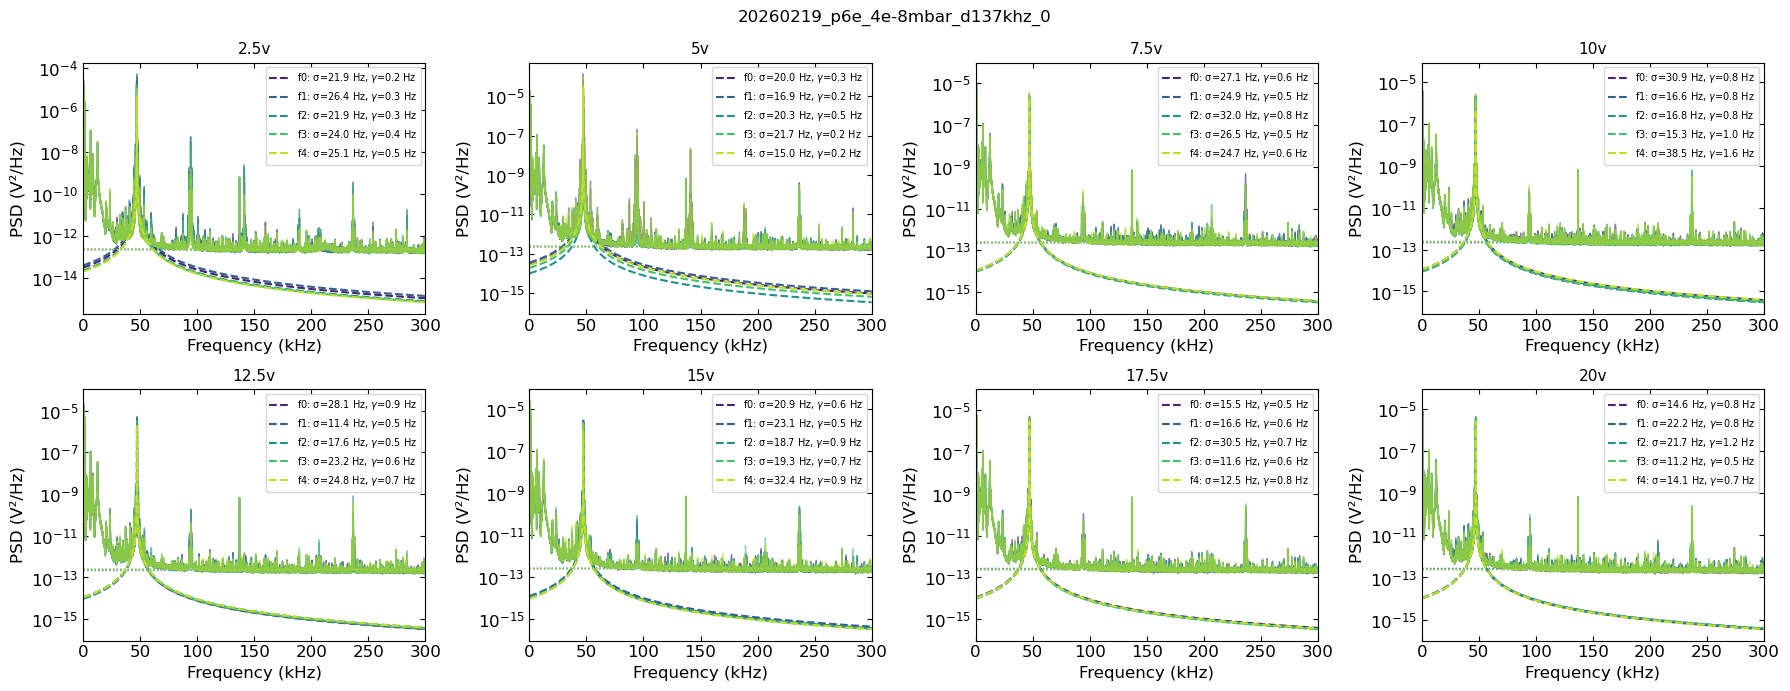

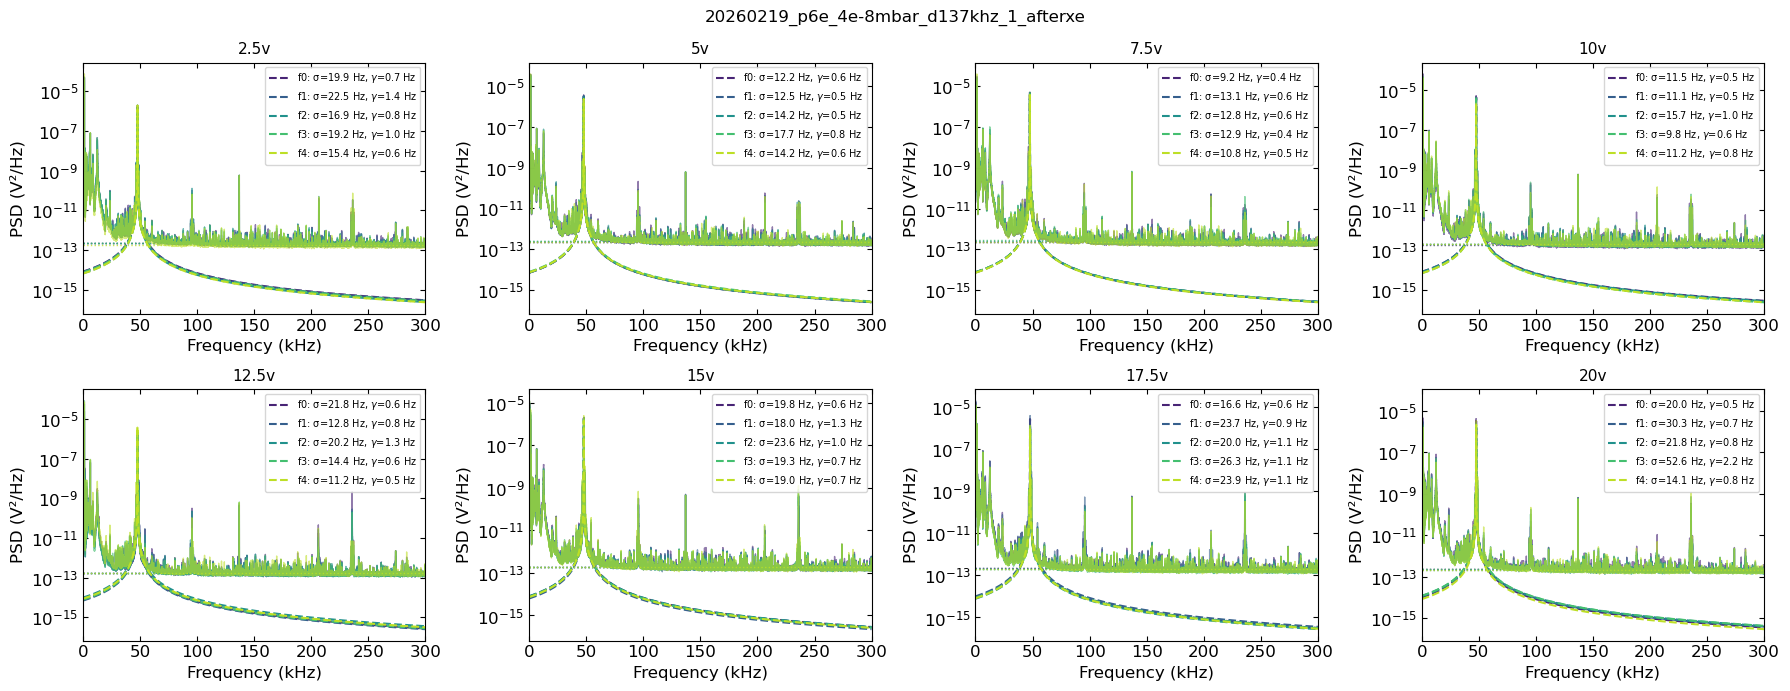

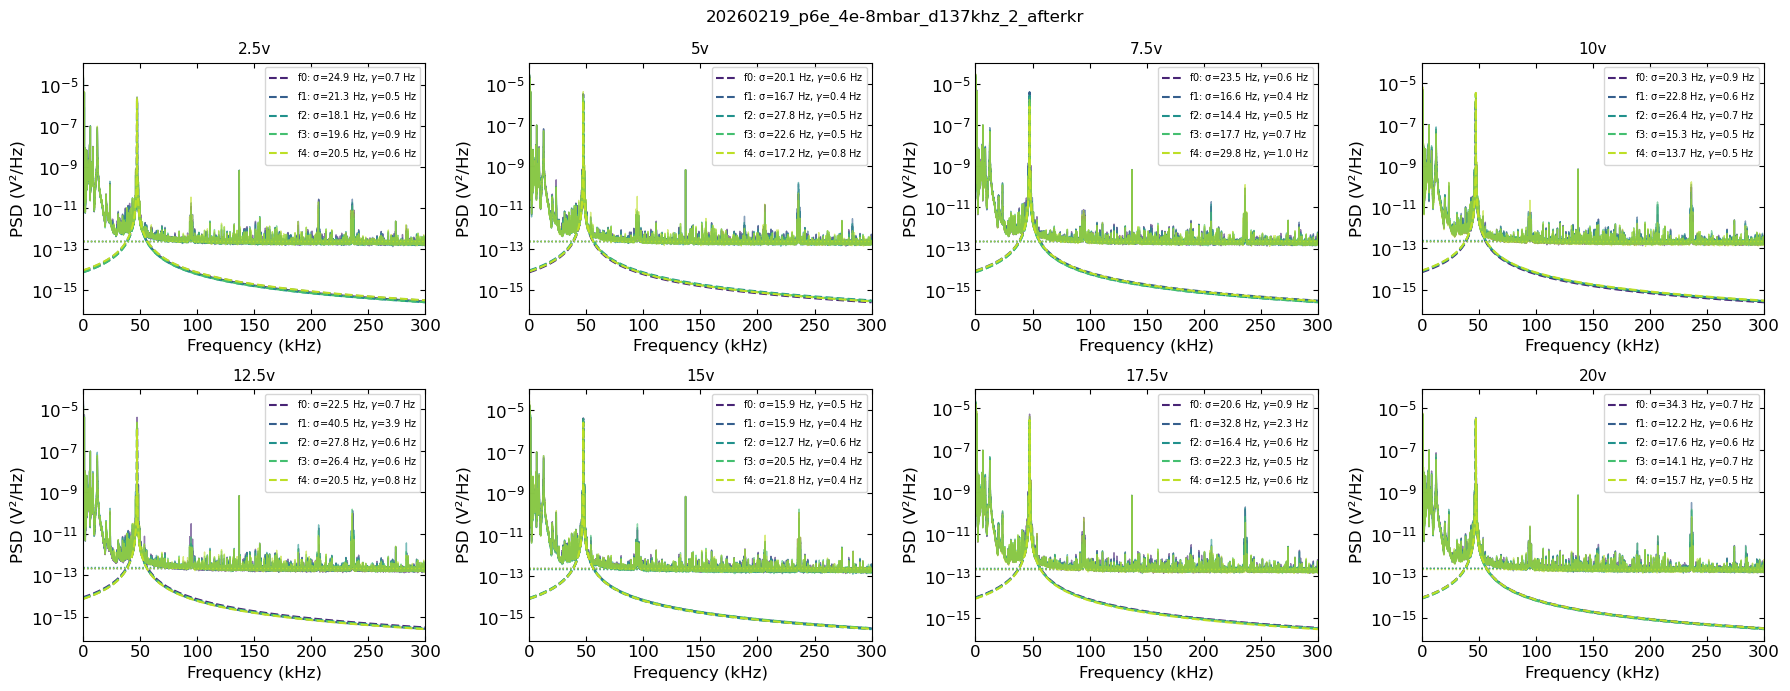

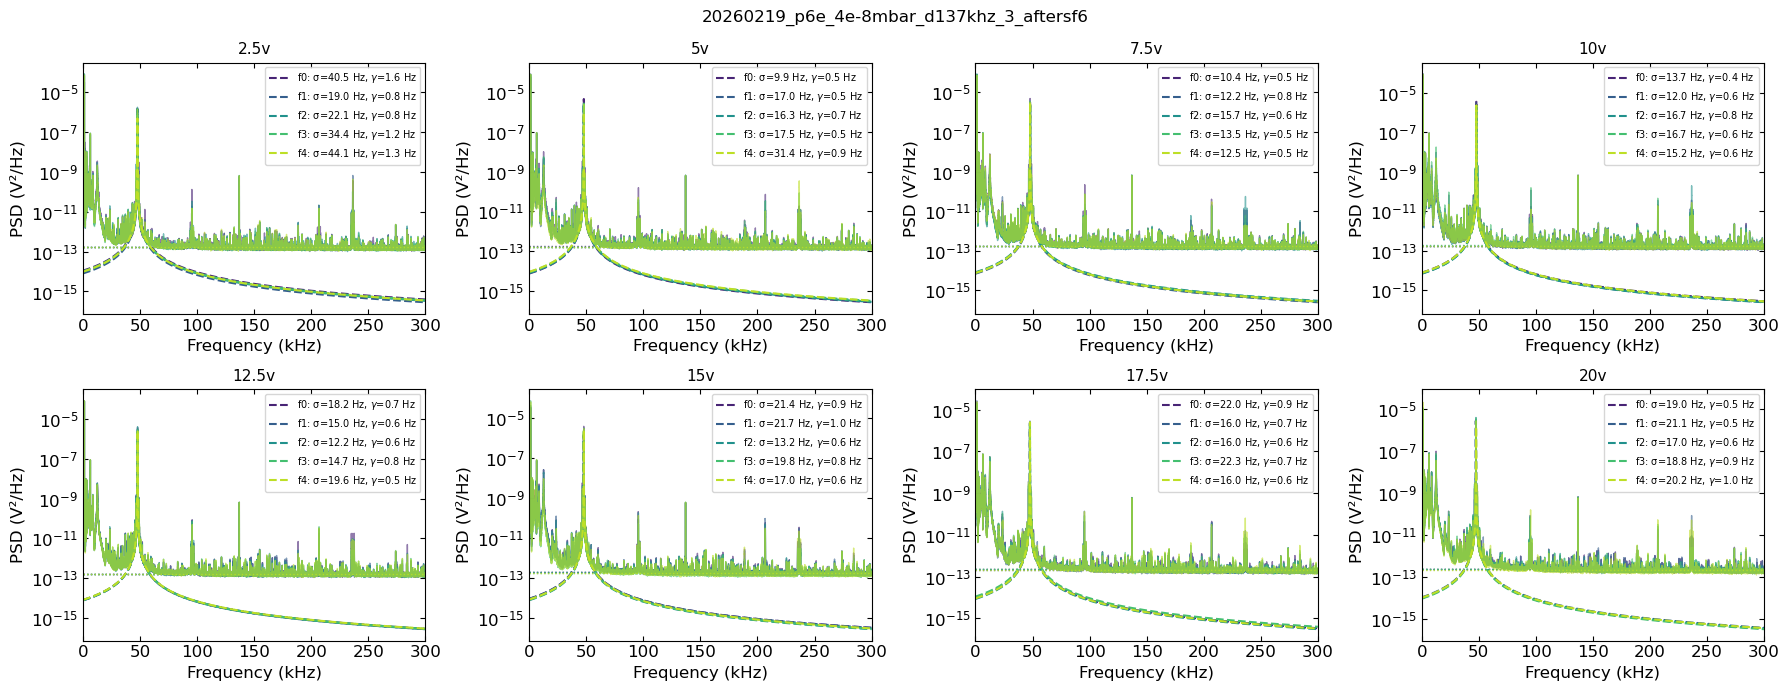

In [46]:

# --- PSD Voigt fit diagnostics: all 4 datasets, all 8 voltages ---
# Each figure = 1 dataset, 2×4 subplots (one per voltage)
# Each subplot overlays all 5 files (PSD + stored Voigt fit + sv_imp noise floor)
_cal_dir = r'/Users/yuhan/work/nanospheres/gas_collisions/data_processed/pulse_calibration/sphere_20260215'
_datasets = [
    '20260219_p6e_4e-8mbar_d137khz_0',
    '20260219_p6e_4e-8mbar_d137khz_1_afterxe',
    '20260219_p6e_4e-8mbar_d137khz_2_afterkr',
    '20260219_p6e_4e-8mbar_d137khz_3_aftersf6',
]
_voltages = ['2.5v', '5v', '7.5v', '10v', '12.5v', '15v', '17.5v', '20v']
_file_colors = plt.colormaps.get_cmap('viridis')(np.linspace(0.1, 0.9, 5))

for _ds in _datasets:
    _hfile = os.path.join(_cal_dir, f'{_ds}_processed.hdf5')
    _fig, _axes = plt.subplots(2, 4, figsize=(18, 7))
    _axes = _axes.flatten()

    with h5py.File(_hfile, 'r') as _f:
        _ffz = _f['data_processed/ffz'][:]
        _plot_idx = _ffz <= 300000  # plot up to 80 kHz
        for _ai, _v in enumerate(_voltages):
            _ax       = _axes[_ai]
            _sv_zs    = _f[f'data_processed/sv_z_{_v}'][:]
            _vparams  = _f[f'data_processed/voigt_params_{_v}'][:]
            _sv_imps  = _f[f'data_processed/sv_imp_{_v}'][:]

            for _i in range(_sv_zs.shape[0]):
                _pp = _sv_zs[_i]
                _A, _omega0, _sigma, _gamma_v = _vparams[_i]
                _sv_imp_i = _sv_imps[_i]

                # PSD up to 80 kHz
                _ax.semilogy(_ffz[_plot_idx]/1e3, _pp[_plot_idx],
                             color=_file_colors[_i], lw=1.0, alpha=0.6)
                # Voigt fit over full range
                _ax.semilogy(_ffz[_plot_idx]/1e3, utils.voigt(_ffz[_plot_idx]*2*np.pi, _A, _omega0, _sigma, _gamma_v),
                             '--', color=_file_colors[_i], lw=1.5,
                             label=fr'f{_i}: σ={_sigma/(2*np.pi):.1f} Hz, $\gamma$={_gamma_v/(2*np.pi):.1f} Hz')
                # sv_imp noise floor
                _ax.axhline(_sv_imp_i, color=_file_colors[_i], lw=1.0, ls=':', alpha=0.8)

            _ax.set_title(_v, fontsize=11)
            _ax.set_xlabel('Frequency (kHz)', fontsize=12)
            _ax.set_ylabel('PSD (V²/Hz)', fontsize=12)
            _ax.set_xlim(0, 300)
            _ax.legend(fontsize=7, loc='upper right')

    _fig.suptitle(_ds, fontsize=12)
    _fig.tight_layout()
    plt.show()


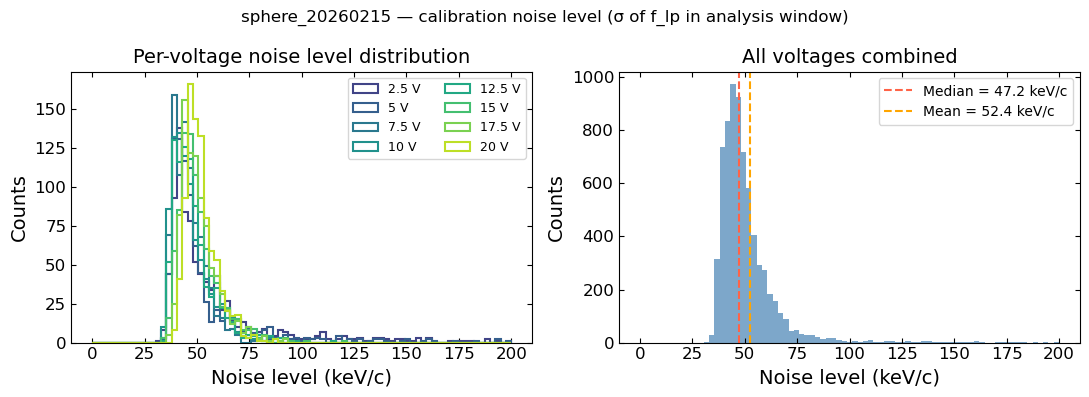

In [47]:
# Plot the noise level distribution from calibration data
noise_level_lists = [noise_level_all_0, noise_level_all_1, noise_level_all_2, noise_level_all_3]

# Per-voltage: concatenate across datasets
noise_per_voltage = [
    np.concatenate([noise_level_lists[j][i] for j in range(len(datasets_all))]) * amp2kev
    for i in range(len(voltages))
]

cmap = plt.colormaps.get_cmap('viridis')
colors = cmap(np.linspace(0.2, 0.9, 8))

bins = np.linspace(0, 200, 80)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for vi, (nl, v) in enumerate(zip(noise_per_voltage, voltages)):
    axes[0].hist(nl, bins=bins, color=colors[vi], histtype='step', linewidth=1.5, label=f'{v} V')

axes[0].set_xlabel('Noise level (keV/c)')
axes[0].set_ylabel('Counts')
axes[0].set_title('Per-voltage noise level distribution')
axes[0].legend(ncol=2, fontsize=9)

all_nl = np.concatenate(noise_per_voltage)
axes[1].hist(all_nl, bins=bins, color='steelblue', histtype='stepfilled', alpha=0.7)
axes[1].axvline(np.median(all_nl), color='tomato', ls='--', label=f'Median = {np.median(all_nl):.1f} keV/c')
axes[1].axvline(np.mean(all_nl),   color='orange', ls='--', label=f'Mean = {np.mean(all_nl):.1f} keV/c')
axes[1].set_xlabel('Noise level (keV/c)')
axes[1].set_ylabel('Counts')
axes[1].set_title('All voltages combined')
axes[1].legend(fontsize=10)

fig.suptitle(f'{sphere} — calibration noise level (σ of f_lp in analysis window)', fontsize=12)
fig.tight_layout()

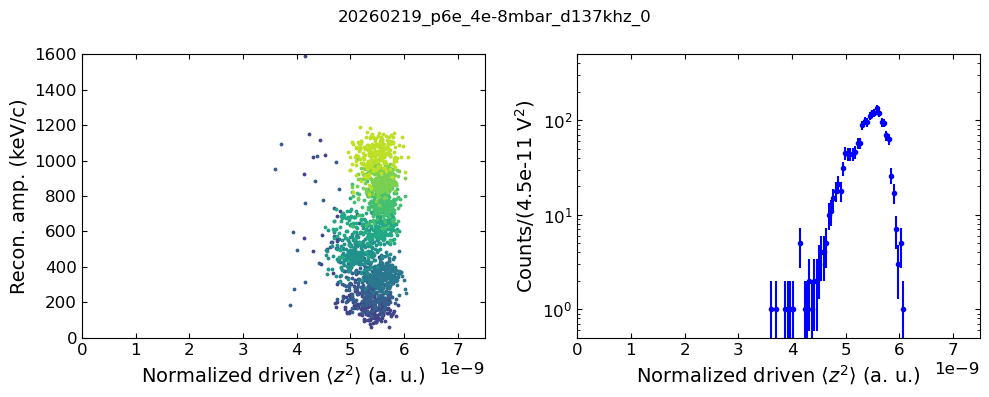

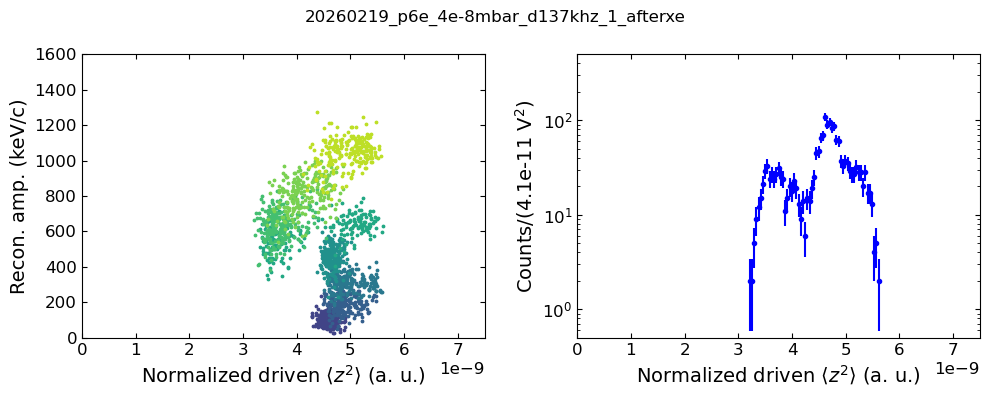

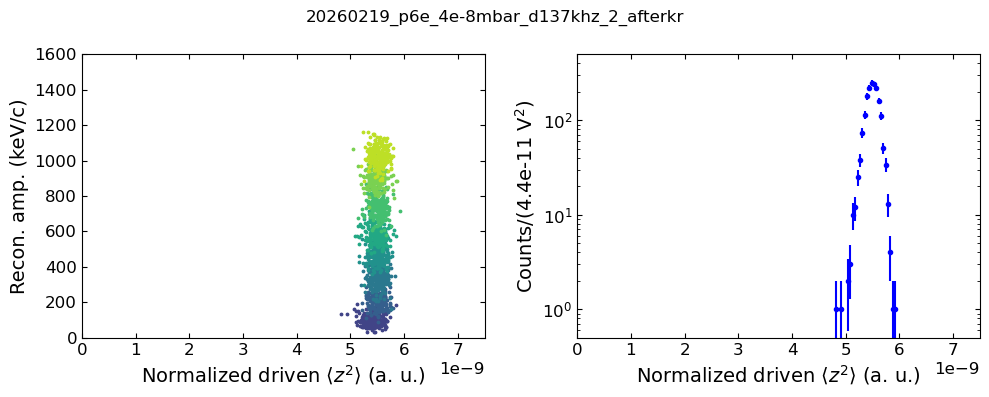

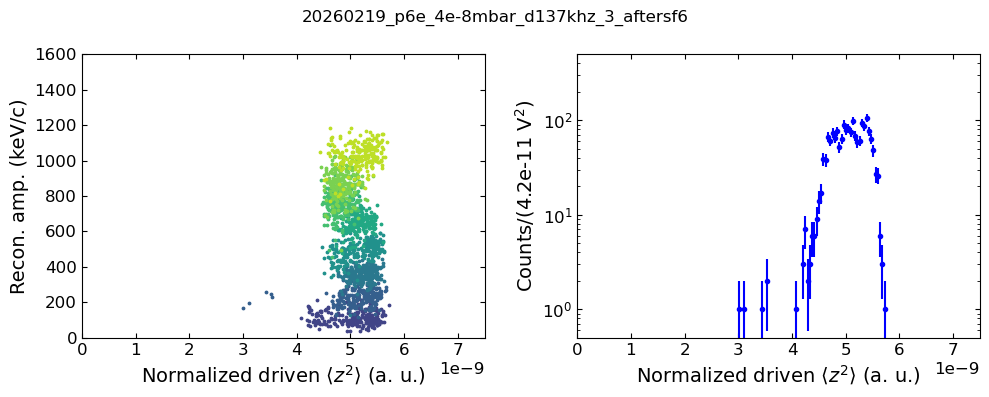

In [48]:
drive_freq = 137000
ref_freq   = 48500

drive_areas = [drive_area_all_0, drive_area_all_1, drive_area_all_2, drive_area_all_3]
amps_lists  = [amps_all_0, amps_all_1, amps_all_2, amps_all_3]
f_res_lists = [f_res_all_0, f_res_all_1, f_res_all_2, f_res_all_3]

for dataset, drive_area, amps, f_res in zip(datasets_all, drive_areas, amps_lists, f_res_lists):
    fig, axes, bc, hh = plot_monitoring(dataset, drive_area, amps, f_res, drive_freq, ref_freq, amp2kev)
    for ax in axes:
        ax.set_xlim(0, 0.75e-8)


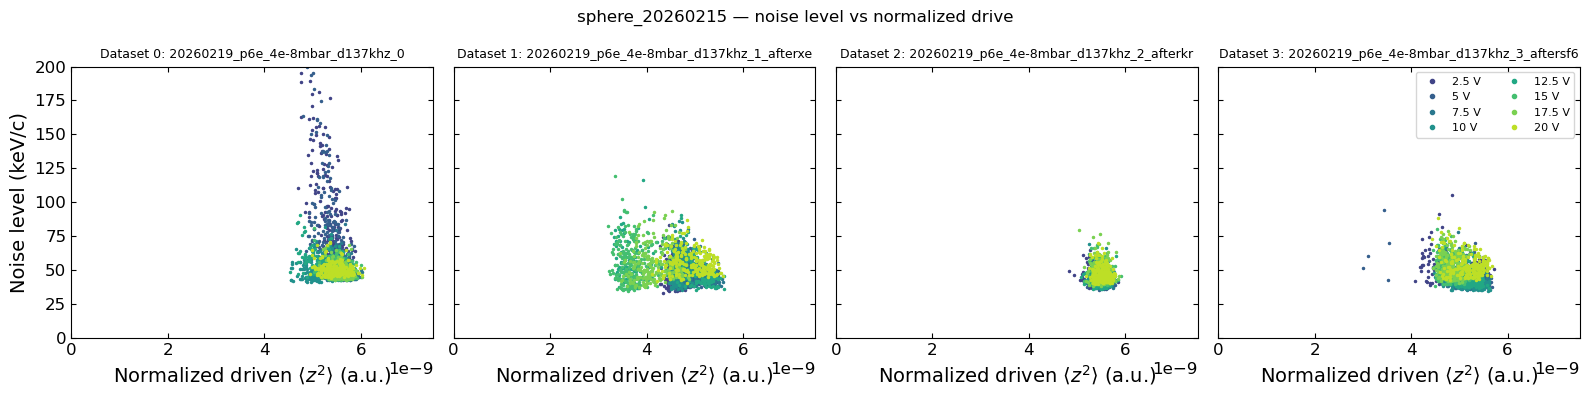

In [68]:
drive_freq = 137000
ref_freq   = 48500

noise_level_lists = [noise_level_all_0, noise_level_all_1, noise_level_all_2, noise_level_all_3]
drive_areas       = [drive_area_all_0,  drive_area_all_1,  drive_area_all_2,  drive_area_all_3]
f_res_lists       = [f_res_all_0,       f_res_all_1,       f_res_all_2,       f_res_all_3]

cmap = plt.colormaps.get_cmap('viridis')
colors = cmap(np.linspace(0.2, 0.9, 8))

fig, axes = plt.subplots(1, len(datasets_all), figsize=(4 * len(datasets_all), 4), sharey=True)

for j, (ax, dataset, drive_area_all, f_res_all, noise_level_all) in enumerate(zip(
        axes, datasets_all, drive_areas, f_res_lists, noise_level_lists)):

    for i in range(8):
        norm = drive_area_all[i] * (f_res_all[i]**2 - drive_freq**2)**2 / ((ref_freq**2 - drive_freq**2)**2)
        ax.plot(norm, noise_level_all[i] * amp2kev, '.', color=colors[i],
                markersize=3, label=f'{voltages[i]} V')

    ax.set_xlim(0, 0.75e-8)
    ax.set_ylim(0, 200)
    ax.set_xlabel(r'Normalized driven $\langle z^2 \rangle$ (a.u.)')
    ax.set_title(f'Dataset {j}: {dataset}', fontsize=9)

axes[0].set_ylabel('Noise level (keV/c)')
axes[-1].legend(fontsize=8, markerscale=2, ncol=2)
fig.suptitle(f'{sphere} — noise level vs normalized drive', fontsize=12)
fig.tight_layout()

#### Selecting pulses in windows with nice detection and noise level

In [49]:
def get_good_amps(amps_all, pulse_shapes_all, indices_in_win, drive_area_all, f_res_all, noise_level_all,
                  drive_freq, ref_freq, threshold, noise_threshold_kev=70):
    good_amps, good_pulses, good_indices = [], [], []
    for i, drive_area in enumerate(drive_area_all):
        normalized_drive_area = drive_area * (f_res_all[i]**2 - drive_freq**2)**2 / ((ref_freq**2 - drive_freq**2)**2)
        mask = (normalized_drive_area > threshold) & (noise_level_all[i] * amp2kev < noise_threshold_kev)
        good_amps.append(amps_all[i][mask])
        good_pulses.append(pulse_shapes_all[i][mask])
        good_indices.append(indices_in_win[i][mask])
    return good_amps, good_pulses, good_indices

In [50]:
drive_freq = 137000
ref_freq = 48500
threshold = 4.5e-9
noise_threshold_kev = 70

drive_areas       = [drive_area_all_0,   drive_area_all_1,   drive_area_all_2,   drive_area_all_3]
amps_lists        = [amps_all_0,         amps_all_1,         amps_all_2,         amps_all_3]
pulse_shapes_lists= [pulse_shapes_all_0, pulse_shapes_all_1, pulse_shapes_all_2, pulse_shapes_all_3]
indices_lists     = [indices_0,          indices_1,          indices_2,          indices_3]
f_res_lists       = [f_res_all_0,        f_res_all_1,        f_res_all_2,        f_res_all_3]
noise_level_lists = [noise_level_all_0,  noise_level_all_1,  noise_level_all_2,  noise_level_all_3]

good_amps_all_datasets = []
good_pulses_all_datasets = []
good_indices_all_datasets = []

for amps, pulses, indices, drive_area, f_res, noise_level in zip(
        amps_lists, pulse_shapes_lists, indices_lists, drive_areas, f_res_lists, noise_level_lists):
    good_amps, good_pulses, good_indices = get_good_amps(
        amps, pulses, indices, drive_area, f_res, noise_level, drive_freq, ref_freq, threshold, noise_threshold_kev)
    
    good_amps_all_datasets.append(good_amps)
    good_pulses_all_datasets.append(good_pulses)
    good_indices_all_datasets.append(good_indices)

for j, dataset in enumerate(datasets_all):
    counts = [len(g) for g in good_amps_all_datasets[j]]
    total_before = sum(len(amps_lists[j][i]) for i in range(8))
    total_after = sum(counts)
    print(f'{dataset}: {total_after}/{total_before} windows pass ({100*total_after/total_before:.1f}%)')

# Collect all the amplitudes/pulse shapes/indices into arrays
_good_amps_all_datasets = []
_good_pulse_shape_all_datasets = []
_good_indices_all_datasets = []
for i in range(8):
    _amps = np.concatenate([good_amps_all_datasets[j][i] for j in range(4)])
    _pulses = np.concatenate([good_pulses_all_datasets[j][i] for j in range(4)], axis=0)
    _indices = np.concatenate([good_indices_all_datasets[j][i] for j in range(len(datasets_all))], axis=0)
    _good_amps_all_datasets.append(_amps)
    _good_pulse_shape_all_datasets.append(_pulses)
    _good_indices_all_datasets.append(_indices)

good_amps_all_datasets = _good_amps_all_datasets
good_pulse_shape_all_datasets = _good_pulse_shape_all_datasets
good_indices_all_datasets = _good_indices_all_datasets

20260219_p6e_4e-8mbar_d137khz_0: 1471/1761 windows pass (83.5%)
20260219_p6e_4e-8mbar_d137khz_1_afterxe: 1118/1762 windows pass (63.5%)
20260219_p6e_4e-8mbar_d137khz_2_afterkr: 1760/1763 windows pass (99.8%)
20260219_p6e_4e-8mbar_d137khz_3_aftersf6: 1689/1760 windows pass (96.0%)


amp2keV: 14460.845035859615


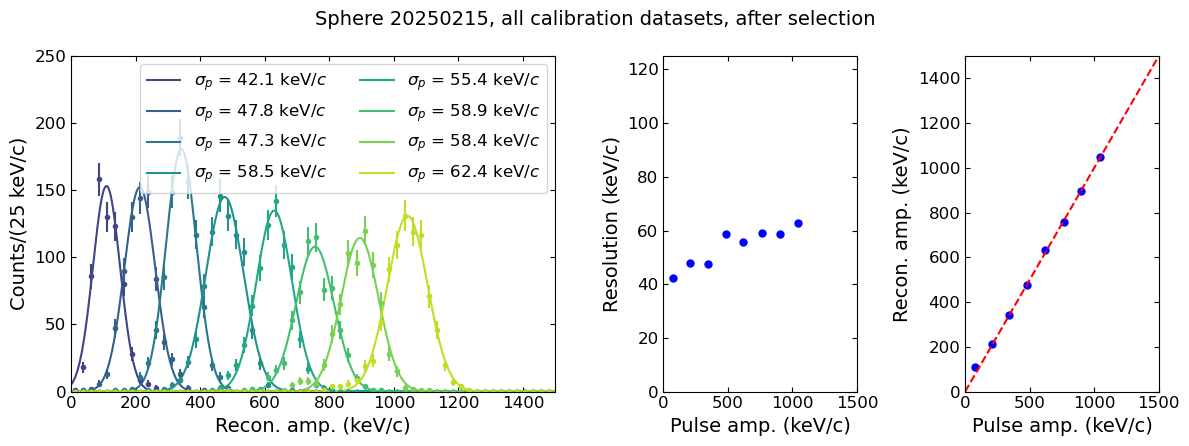

In [51]:
from scipy.optimize import curve_fit

def model_func(x, a):
    return a * x

amp2kev_bin = 14458.5
bins = np.arange(0, 3000, 25) / amp2kev_bin
pulse_amp = np.asarray([74, 209, 342, 482, 618, 764, 901, 1046])

cmap = plt.colormaps.get_cmap('viridis')
colors = cmap(np.linspace(0.2, 0.9, 8))

fig, axes = plt.subplots(1, 3, figsize=(12, 4.5), width_ratios=[2.5, 1, 1])
hhs_good, bcs_good, gps_good = utils.fit_amps_gaus(good_amps_all_datasets, bins=bins, noise=False, return_bins=False)

xx = np.linspace(0, np.max(bcs[0]), 1000)
for i in range(8):
    axes[0].errorbar(bcs_good[i]*amp2kev, hhs_good[i], yerr=np.sqrt(hhs_good[i]), fmt='.', color=colors[i])
    axes[0].plot(xx*amp2kev, utils.gauss(xx, *gps_good[i]), label=fr'$\sigma_p$ = {gps_good[i][2]*amp2kev:.1f} keV/$c$', color=colors[i])

amp2kevs = pulse_amp / np.asarray(gps_good).T[1]
amp2kev = curve_fit(model_func, np.asarray(gps_good).T[1][2:], pulse_amp[2:])[0][0]
print(f'amp2keV: {amp2kev}')

axes[0].legend(ncol=2)
axes[0].set_xlim(0, 1500)
axes[0].set_ylim(0, 250)
axes[0].set_xlabel('Recon. amp. (keV/c)')
axes[0].set_ylabel('Counts/(25 keV/c)')

axes[1].plot(pulse_amp, np.asarray(gps_good).T[2]*amp2kev, 'b.', markersize=10)
axes[1].set_xlim(0, 1500)
axes[1].set_ylim(0, 125)
axes[1].set_xlabel('Pulse amp. (keV/c)')
axes[1].set_ylabel('Resolution (keV/c)')

axes[2].plot(pulse_amp, np.asarray(gps_good).T[1]*amp2kev, 'b.', markersize=10)
axes[2].plot(np.linspace(0, 1500, 50), np.linspace(0, 1500, 50), 'r--')
axes[2].set_xlim(0, 1500)
axes[2].set_ylim(0, 1500)
axes[2].set_xlabel('Pulse amp. (keV/c)')
axes[2].set_ylabel('Recon. amp. (keV/c)')

fig.suptitle('Sphere 20250215, all calibration datasets, after selection', fontsize=14)
fig.tight_layout()

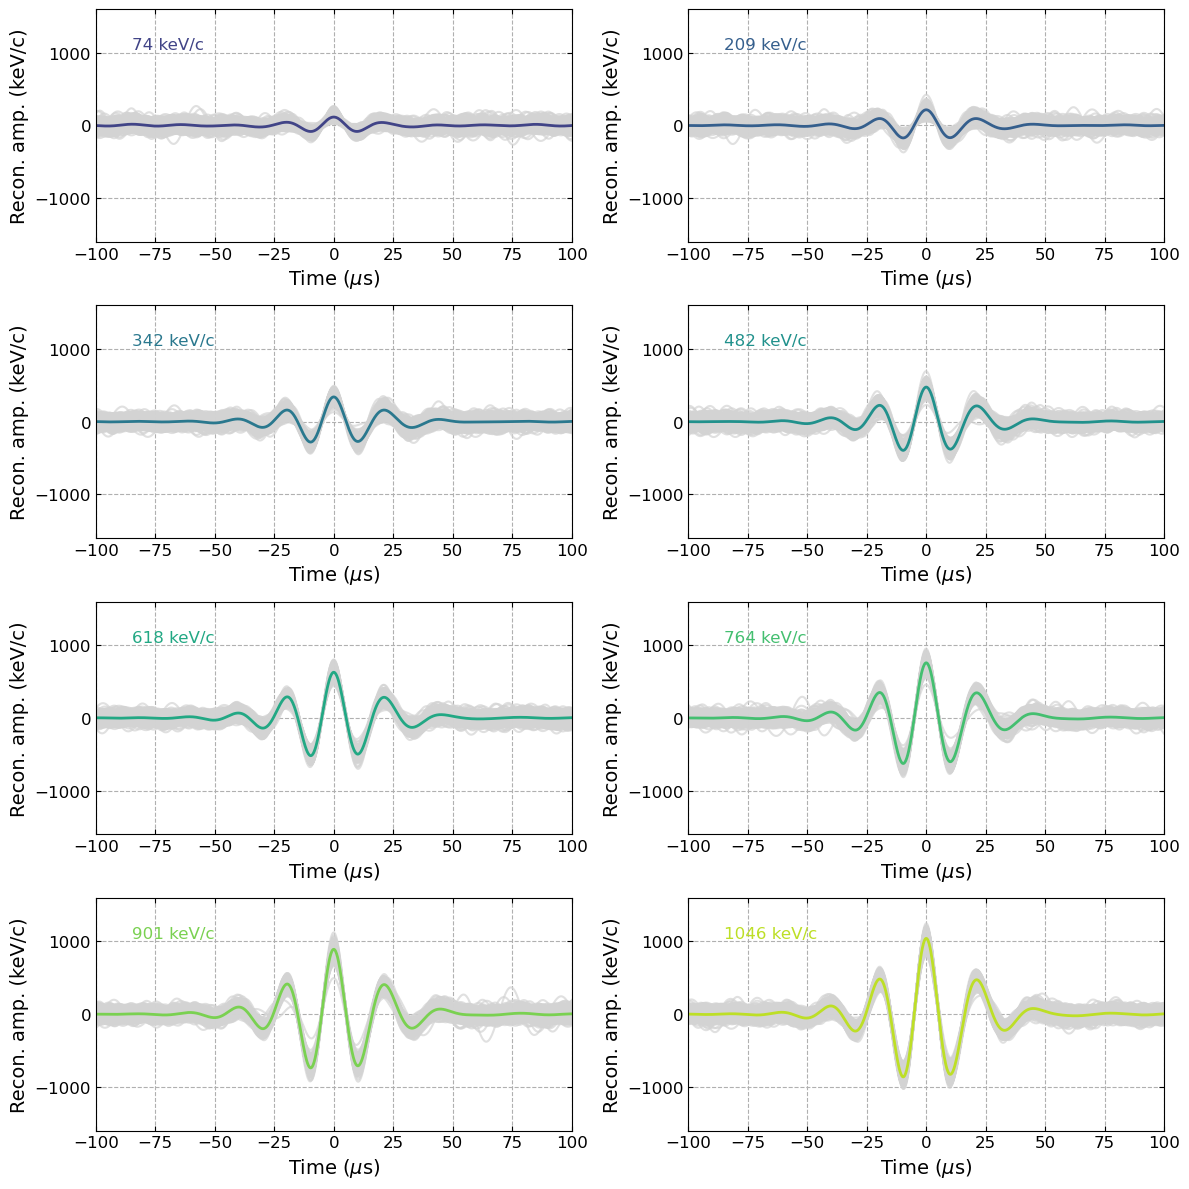

In [52]:
## Form templates by averaging the reconstructed waveform
pulse_shape_template_all = [np.mean(pulses, axis=0) for pulses in good_pulse_shape_all_datasets]
tt = 200e-9 * np.arange(3000)

fig, axes = plt.subplots(4 ,2, figsize=(12, 12))
for i, good_pulse in enumerate(good_pulse_shape_all_datasets):
    ax = axes.flatten()[i]
    
    for j in range(good_pulse.shape[0]):
        ax.plot(tt/1e-6-300, amp2kev*good_pulse[j], color='lightgray', alpha=0.7)

    ax.plot(tt/1e-6 - 300, amp2kev*np.mean(good_pulse, axis=0), color=colors[i], linewidth=2)

    ax.set_xlabel(r'Time ($\mu$s)')
    ax.set_ylabel(r'Recon. amp. (keV/c)')

    ax.text(-85, 1050, f'{pulse_amp[i]} keV/c', fontsize=12, color=colors[i])
    ax.set_xlim(-100, 100)
    ax.set_ylim(-1600, 1600)

    ax.grid(linestyle='--')

fig.tight_layout()

In [53]:
# Save the averaged calibration waveform as template, plus all individual waveforms after selection
np.savez(
    rf'/Users/yuhan/work/nanospheres/gas_collisions/data_processed/pulse_calibration/{sphere}/sphere_20260215_impulse_recon_combined.npz',
    ps_2_5v=pulse_shape_template_all[0],
    ps_5v=pulse_shape_template_all[1],
    ps_7_5v=pulse_shape_template_all[2],
    ps_10v=pulse_shape_template_all[3],
    ps_12_5v=pulse_shape_template_all[4],
    ps_15v=pulse_shape_template_all[5],
    ps_17_5v=pulse_shape_template_all[6],
    ps_20v=pulse_shape_template_all[7],
    pulse_amp_kev=pulse_amp,
    amp2kev=amp2kev,
    # Individual waveforms (N_pulses, 3000) used to form each template
    ind_2_5v=good_pulse_shape_all_datasets[0],
    ind_5v=good_pulse_shape_all_datasets[1],
    ind_7_5v=good_pulse_shape_all_datasets[2],
    ind_10v=good_pulse_shape_all_datasets[3],
    ind_12_5v=good_pulse_shape_all_datasets[4],
    ind_15v=good_pulse_shape_all_datasets[5],
    ind_17_5v=good_pulse_shape_all_datasets[6],
    ind_20v=good_pulse_shape_all_datasets[7],
    # Reconstructed amplitudes (N_pulses,) for each voltage
    amp_2_5v=good_amps_all_datasets[0],
    amp_5v=good_amps_all_datasets[1],
    amp_7_5v=good_amps_all_datasets[2],
    amp_10v=good_amps_all_datasets[3],
    amp_12_5v=good_amps_all_datasets[4],
    amp_15v=good_amps_all_datasets[5],
    amp_17_5v=good_amps_all_datasets[6],
    amp_20v=good_amps_all_datasets[7],

    # Pulse timing indices in window (N_pulses,) for each voltage
    idx_2_5v=good_indices_all_datasets[0],
    idx_5v=good_indices_all_datasets[1],
    idx_7_5v=good_indices_all_datasets[2],
    idx_10v=good_indices_all_datasets[3],
    idx_12_5v=good_indices_all_datasets[4],
    idx_15v=good_indices_all_datasets[5],
    idx_17_5v=good_indices_all_datasets[6],
    idx_20v=good_indices_all_datasets[7],
)

## Other analysis choices

In [15]:
# ── Parameters ────────────────────────────────────────────────────────────
bandpass_lb            = 35000
bandpass_ub            = 80000
lowpass_order          = 3

notch_freq             = 137000
fit_window_length      = 2**19
analysis_window_length = 2**18
search_window_length   = 2**8
positive_pulse         = True

data_prefix = '20260219_dfg_p6e_200ns_'
data_folder = r'/Volumes/LaCie/gas_collisions/pulse_calibration/sphere_20260215/20260219_p6e_4e-8mbar_d137khz_0'

In [16]:
# ── Load and pre-process all 5 20 V files ──────────────────────────────────
_files_20v = sorted(glob.glob(os.path.join(data_folder, f'{data_prefix}20v*.hdf5')))
print(f'Using {len(_files_20v)} 20 V file(s),  reference amplitude = {pulse_amp[-1]} keV/c')

_preprocessed = []
for _f in _files_20v:
    _dtt, _nn = utils.load_timestreams(_f, ['D', 'G'])
    _fs  = int(np.ceil(1 / _dtt))
    _zz, _dd = _nn[0], _nn[1]

    _zz_notched = utils.notch_filtered(_zz, _fs, f0=notch_freq, q=50)

    _p_fit, _sv_imp, _, _ = utils.get_sv_imp(
        _fs, _zz, fit_band=(40000, 60000), noise_band=(110000, 120000),
        nperseg=2**18, p0=[5e-4, 48381*2*np.pi, 100*2*np.pi, 1*2*np.pi])
    _A, _omega0, _sigma_voigt, _gamma_voigt = _p_fit
    _gamma_fit = _gamma_voigt * 2   # damping of the oscillator from voigt fit

    # c_imp_voigt: calibration constant computed with Voigt-fit gamma
    # c_imp = sv_imp * pi / (omega0^2 * gamma * A)
    _c_imp_voigt = _sv_imp * (np.pi / (_omega0**2 * _gamma_fit * _A))

    _preprocessed.append((_dtt, _fs, _zz_notched, _dd, _omega0, _c_imp_voigt, _gamma_fit))
    print(f'  {os.path.basename(_f)}: A={_A}, f₀={_omega0/(2*np.pi)/1e3:.3f} kHz, sigma={_sigma_voigt/(2*np.pi):.2f} Hz, '
          f'γ_fit={_gamma_fit/(2*np.pi):.2f} Hz, c_imp={_c_imp_voigt:.3e}')

Using 5 20 V file(s),  reference amplitude = 1046 keV/c
  20260219_dfg_p6e_200ns_20v_0.hdf5: A=0.0006044346432536608, f₀=47.326 kHz, sigma=17.46 Hz, γ_fit=1.51 Hz, c_imp=1.563e-21
  20260219_dfg_p6e_200ns_20v_1.hdf5: A=0.0007889574524842002, f₀=47.324 kHz, sigma=23.76 Hz, γ_fit=1.24 Hz, c_imp=1.557e-21
  20260219_dfg_p6e_200ns_20v_2.hdf5: A=0.000500310797193386, f₀=47.331 kHz, sigma=23.33 Hz, γ_fit=1.90 Hz, c_imp=1.607e-21
  20260219_dfg_p6e_200ns_20v_3.hdf5: A=0.0009966753041531647, f₀=47.309 kHz, sigma=14.69 Hz, γ_fit=0.97 Hz, c_imp=1.535e-21
  20260219_dfg_p6e_200ns_20v_4.hdf5: A=0.0006420529313258378, f₀=47.309 kHz, sigma=17.62 Hz, γ_fit=1.42 Hz, c_imp=1.587e-21


In [17]:
# ── Core helper functions ─────────────────────────────────────────────────
# reconstruct_pulses closes over notebook globals:
#   positive_pulse, analysis_window_length, fit_window_length, search_window_length

def reconstruct_pulses(preprocessed, c_imp=None, gamma_recon_hz=None,
                       bandpass_lb=None, bandpass_ub=None, lowpass_order=None):
    """
    Reconstruct calibration pulses from preprocessed data.

    c_imp          : float | callable(c_imp_voigt, gamma_fit) -> float | None
                     Fixed value, per-file callable, or None for Voigt c_imp.
    gamma_recon_hz : float | None
                     Fixed gamma_recon in Hz, or None for per-file Voigt gamma.
    bandpass_lb    : float  lower bandpass cutoff (Hz)
    bandpass_ub    : float  upper bandpass cutoff (Hz)
    lowpass_order  : int    lowpass filter order for reconstruction

    Returns shapes (N, 3000) and amps (N,) in raw units.
    """
    shapes, amps = [], []
    for (dtt, fs, zz_notched, dd, omega0, c_imp_voigt, gamma_fit) in preprocessed:
        zz_bp = utils.bandpass_filtered(zz_notched, fs, bandpass_lb, bandpass_ub, order=lowpass_order)

        if c_imp is None:
            _c_imp = c_imp_voigt
        elif callable(c_imp):
            _c_imp = c_imp(c_imp_voigt, gamma_fit)
        else:
            _c_imp = c_imp

        _gamma_recon = gamma_fit if gamma_recon_hz is None else gamma_recon_hz * 2 * np.pi

        for idx in utils.get_pulse_idx(dd, 0.5 * positive_pulse, positive_pulse):
            window, f, f_lp, amp = utils.recon_pulse(
                idx, dtt, zz_bp, dd, _c_imp, _gamma_recon,
                analysis_window_length, fit_window_length,
                search_window_length, 20, bandpass_ub, lowpass_order)
            if window is None:
                continue
            peak_i   = np.argmin(np.abs(np.abs(f_lp) - amp))
            polarity = 1 if f_lp[peak_i] > 0 else -1
            seg      = polarity * f_lp[peak_i - 1500 : peak_i + 1500]
            if seg.size == 3000:
                shapes.append(seg)
                amps.append(amp)
    return np.asarray(shapes), np.asarray(amps)

def fit_amp2kev(amps, pulse_amp_ref=None, amp2kev_fallback=None):
    """
    Fit a Gaussian to the amplitude histogram to derive amp2kev.
    Returns (gp, amp2kev); gp = [height, mean, sigma] in raw units,
    or (None, amp2kev_fallback) on failure.
    """
    if pulse_amp_ref    is None: pulse_amp_ref    = pulse_amp[-1]

    bins_raw = np.linspace(0, np.max(amps) * 1.2, 80)
    hh_raw, be_raw = np.histogram(amps, bins=bins_raw)
    bc_raw = 0.5 * (be_raw[1:] + be_raw[:-1])
    try:
        gp, _ = curve_fit(utils.gauss, bc_raw, hh_raw,
                          p0=[np.max(hh_raw), np.mean(amps), np.std(amps)],
                          bounds=([0, np.inf]), maxfev=50000)
        a2k = pulse_amp_ref / gp[1]
    except Exception:
        gp, a2k = None, amp2kev_fallback
    return gp, a2k

def plot_recon_summary(shapes, amps, gp, a2k, ax_wave, ax_hist, title=''):
    """
    Plot centred waveform overlay + amplitude histogram onto provided axes.
    shapes/amps in raw units; a2k converts to keV/c.
    """
    dtt_ref = _preprocessed[0][0]
    tt_us   = (np.arange(3000) - 1500) * dtt_ref / 1e-6

    for ps in shapes:
        ax_wave.plot(tt_us, ps * a2k, color='lightgrey', lw=0.6, alpha=0.4)
    ax_wave.plot(tt_us, shapes.mean(axis=0) * a2k, color='steelblue', lw=2)
    ax_wave.set_xlim(-100, 100)
    ax_wave.set_xlabel(r'Time ($\mu$s)')
    ax_wave.set_ylabel('Recon. amp. (keV/c)')
    ax_wave.set_title(title, fontsize=10)

    bins_kev = np.arange(0, 2000, 25)
    hh_kev, be_kev = np.histogram(amps * a2k, bins=bins_kev)
    bc_kev = 0.5 * (be_kev[1:] + be_kev[:-1])
    ax_hist.errorbar(bc_kev, hh_kev, yerr=np.sqrt(hh_kev), fmt='.', color='steelblue', markersize=4)
    if gp is not None:
        xx_kev = np.linspace(0, 2000, 500)
        # Scale Gaussian height from fit bin width to display bin width
        dbin_fit     = np.max(amps) * 1.2 / 79   # raw units, 80 bins → 79 intervals
        dbin_display = 25 / a2k                   # raw units (25 keV bins)
        scale = dbin_display / dbin_fit
        ax_hist.plot(xx_kev, scale * utils.gauss(xx_kev / a2k, *gp), 'r-', lw=1.5,
                     label=fr'$\mu$ = {gp[1]*a2k:.0f}, $\sigma$ = {gp[2]*a2k:.0f} keV/c')
        ax_hist.legend(fontsize=9)
    ax_hist.set_xlabel('Recon. amp. (keV/c)')
    ax_hist.set_ylabel('Counts')
    ax_hist.set_xlim(0, 2000)


# ── run_gamma_scan ────────────────────────────────────────────────────────

def run_gamma_scan(preprocessed, gamma_scan_hz, c_imp_scaling=None,
                   bandpass_lb=None, bandpass_ub=None, lowpass_order=None, **kwargs):
    """
    Scan pulse reconstruction over gamma_recon values.
    The Voigt-fit gamma is always appended as the final reference column.

    c_imp_scaling  : float | None
                     Direct multiplicative scale applied to the stored Voigt-fit c_imp.
                     None → use Voigt c_imp as-is (per file).
    bandpass_lb    : float  lower bandpass cutoff (Hz)
    bandpass_ub    : float  upper bandpass cutoff (Hz)
    lowpass_order  : int    lowpass filter order for reconstruction
    """
    if c_imp_scaling is None:
        c_imp_fn = None
    else:
        c_imp_fn = lambda cv, gf: cv * c_imp_scaling

    mean_gamma_voigt_hz = np.mean([p[6] / (2 * np.pi) for p in preprocessed])
    n_cols = len(gamma_scan_hz) + 1
    fig, axes = plt.subplots(2, n_cols, figsize=(4 * n_cols, 7))

    for col, ghz in enumerate(gamma_scan_hz):
        shapes, amps = reconstruct_pulses(preprocessed, c_imp=c_imp_fn, gamma_recon_hz=ghz,
                                          bandpass_lb=bandpass_lb, bandpass_ub=bandpass_ub,
                                          lowpass_order=lowpass_order)
        gp, a2k = fit_amp2kev(amps)
        plot_recon_summary(shapes, amps, gp, a2k, axes[0, col], axes[1, col],
                           title=(fr'$\gamma_\mathrm{{recon}}$ = {ghz:.1f} Hz'
                                  + (f'\namp2kev={a2k:.0f}' if gp is not None else '')))
        print(f'γ_recon = {ghz:.1f} Hz → {len(amps)} pulses, amp2kev = {a2k:.0f}')

    # Voigt reference column
    shapes_v, amps_v = reconstruct_pulses(preprocessed, c_imp=c_imp_fn, gamma_recon_hz=None,
                                          bandpass_lb=bandpass_lb, bandpass_ub=bandpass_ub,
                                          lowpass_order=lowpass_order)
    gp_v, a2k_v = fit_amp2kev(amps_v)
    voigt_title = (fr'Voigt $\gamma_\mathrm{{recon}}$' + '\n'
                   + fr'(mean {mean_gamma_voigt_hz:.2f} Hz)'
                   + (f'\namp2kev={a2k_v:.0f}' if gp_v is not None else ''))
    plot_recon_summary(shapes_v, amps_v, gp_v, a2k_v, axes[0, -1], axes[1, -1], title=voigt_title)
    for row in range(2):
        for spine in axes[row, -1].spines.values():
            spine.set_edgecolor('darkorange')
            spine.set_linewidth(2)
    print(f'Voigt γ_recon (mean {mean_gamma_voigt_hz:.2f} Hz) → {len(amps_v)} pulses, amp2kev = {a2k_v:.0f}')

    c_imp_label = ('Voigt (per file)' if c_imp_scaling is None
                   else fr'Voigt × {c_imp_scaling}')
    fig.suptitle(
        fr'$\gamma_\mathrm{{recon}}$ scan  |  $c_\mathrm{{imp}}$: {c_imp_label}' + '\n'
        + f'bp: {bandpass_lb/1e3:.0f}–{bandpass_ub/1e3:.0f} kHz, order {lowpass_order}',
        fontsize=12)
    fig.tight_layout()
    return fig, axes

Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
c_imp = 1.57e-22 → 220 pulses, amp2kev = 10527
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
c_imp = 3.14e-22 → 220 pulses, amp2kev = 12350
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
c_imp = 7.85e-22 → 220 pulses, amp2kev = 16036
Skipping pulse too close to the beginning of the 

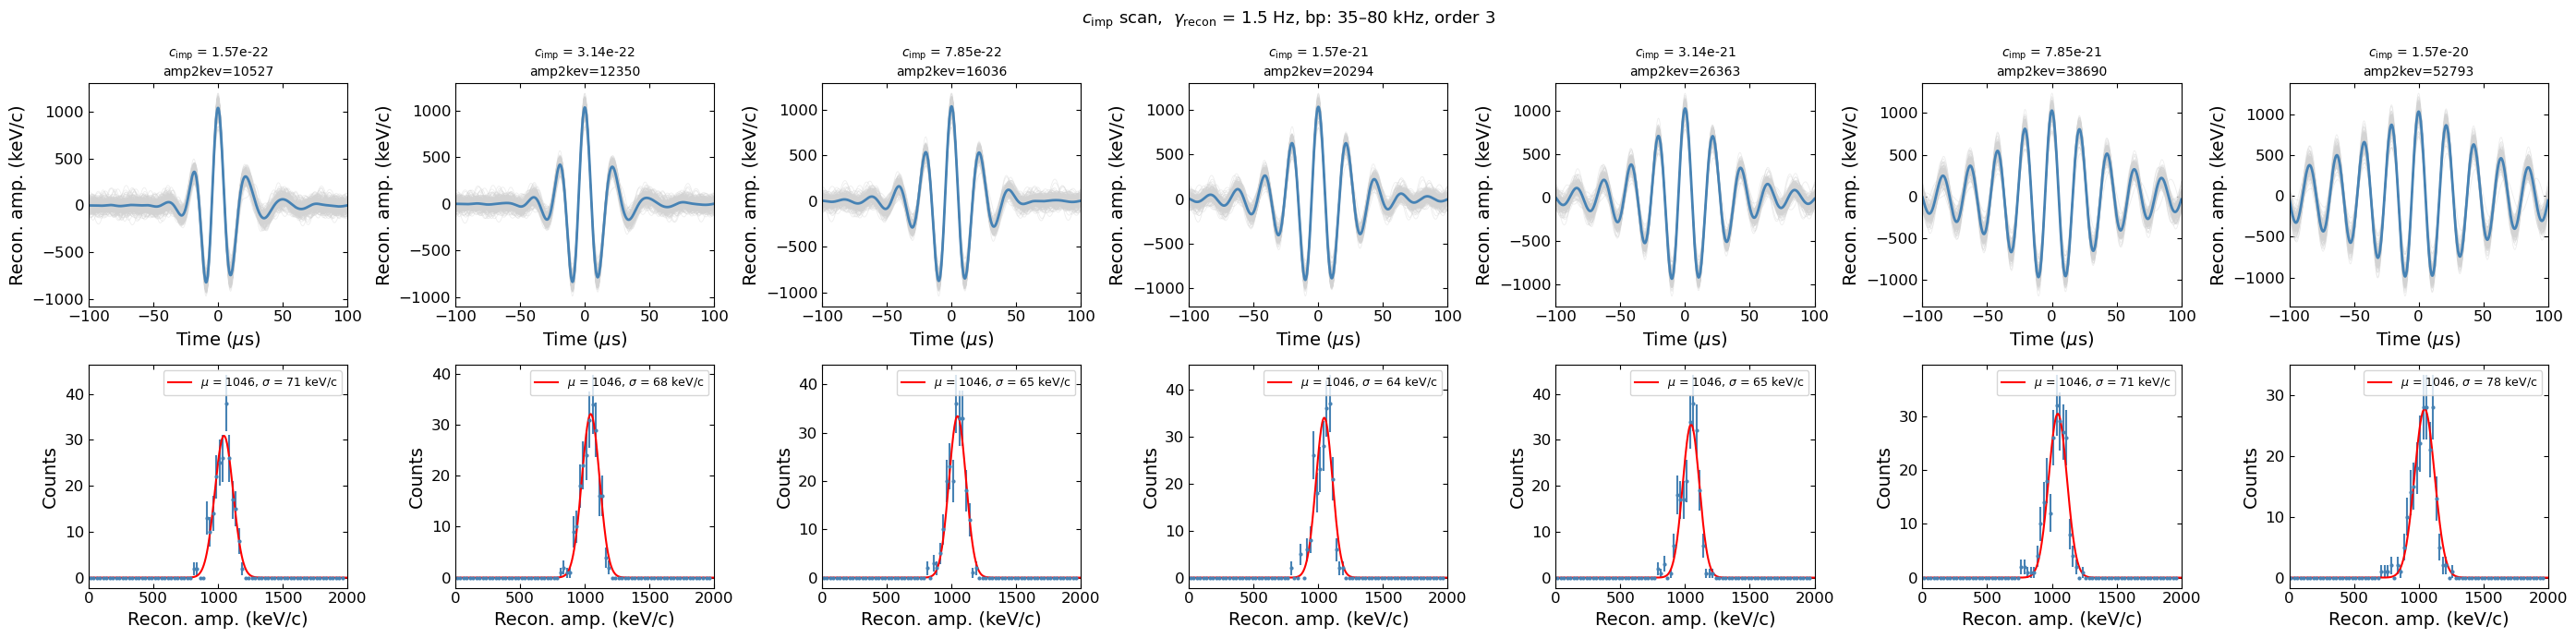

In [18]:
# ── Parameters ───────────────────────────────────────────────────────────
bandpass_lb   = 35000
bandpass_ub   = 80000
lowpass_order = 3

gamma_recon_hz = 1.5    # Hz; None = per-file Voigt

# Scan over c_imp values — use a single float for a one-off reconstruction
c_imp_voigt_avg = np.mean(np.asarray([_preprocessed[i][-2] for i in range(5)]))
c_imp_scan = np.asarray([1/10, 1/5, 1/2, 1, 2, 5, 10]) * c_imp_voigt_avg

# ── Run ──────────────────────────────────────────────────────────────────
c_imp_values = np.atleast_1d(c_imp_scan)
n = len(c_imp_values)
fig, axes = plt.subplots(2, n, figsize=(4 * n, 7), squeeze=False)

for col, c_imp_val in enumerate(c_imp_values):
    shapes, amps = reconstruct_pulses(_preprocessed, c_imp=float(c_imp_val), gamma_recon_hz=gamma_recon_hz,
                                      bandpass_lb=bandpass_lb, bandpass_ub=bandpass_ub, lowpass_order=lowpass_order)
    gp, a2k = fit_amp2kev(amps)
    plot_recon_summary(shapes, amps, gp, a2k, axes[0, col], axes[1, col],
                       title=(fr'$c_\mathrm{{imp}}$ = {c_imp_val:.2e}'
                              + (f'\namp2kev={a2k:.0f}' if gp is not None else '')))
    print(f'c_imp = {c_imp_val:.2e} → {len(amps)} pulses, amp2kev = {a2k:.0f}')

gamma_str = f'{gamma_recon_hz} Hz' if gamma_recon_hz is not None else 'Voigt (per file)'
fig.suptitle(fr'$c_\mathrm{{imp}}$ scan,  $\gamma_\mathrm{{recon}}$ = {gamma_str}, '
             + f'bp: {bandpass_lb/1e3:.0f}–{bandpass_ub/1e3:.0f} kHz, order {lowpass_order}', fontsize=13)
fig.tight_layout()
plt.show()

First fix c_imp using gamma from the voigt fit, and manually change gamma_recon used in mechanical susceptibility

Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
γ_recon = 0.1 Hz → 220 pulses, amp2kev = 20309
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
γ_recon = 1.0 Hz → 220 pulses, amp2kev = 20306
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
γ_recon = 10.0 Hz → 220 pulses, amp2kev = 20316
Skipping pulse too close to the beginning of the

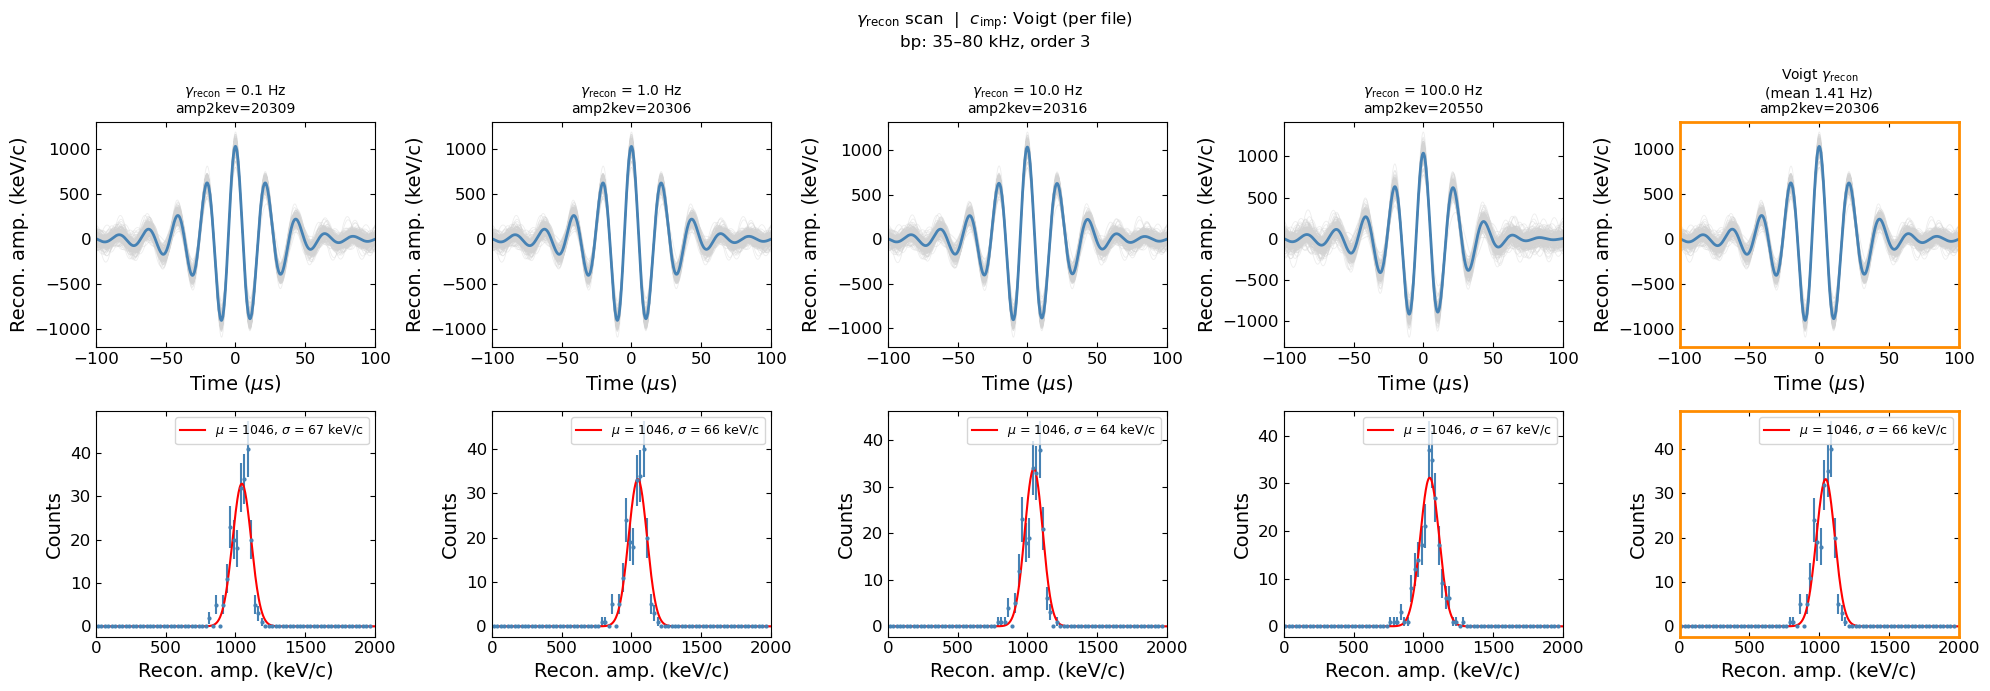

In [19]:
# ── Shared reconstruction kwargs (everything except bandpass/lowpass) ─────
_kw_base = dict(pulse_amp_ref=pulse_amp[-1], amp2kev_fallback=None,
                analysis_window_length=analysis_window_length,
                fit_window_length=fit_window_length,
                search_window_length=search_window_length,
                positive_pulse=positive_pulse)

# ── Parameters ────────────────────────────────────────────────────────────
bandpass_lb   = 35000
bandpass_ub   = 80000
lowpass_order = 3
gamma_scan_hz = np.asarray([0.1, 1, 10, 100])   # gamma_recon fixed values to scan (Hz)

# c_imp via Voigt-fit (no scaling)
fig, axes = run_gamma_scan(_preprocessed, gamma_scan_hz, c_imp_scaling=None,
                           bandpass_lb=bandpass_lb, bandpass_ub=bandpass_ub, lowpass_order=lowpass_order,
                           **_kw_base)
plt.show()

Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
γ_recon = 0.1 Hz → 220 pulses, amp2kev = 16034
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
γ_recon = 1.0 Hz → 220 pulses, amp2kev = 16034
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
γ_recon = 10.0 Hz → 220 pulses, amp2kev = 16065
Skipping pulse too close to the beginning of the

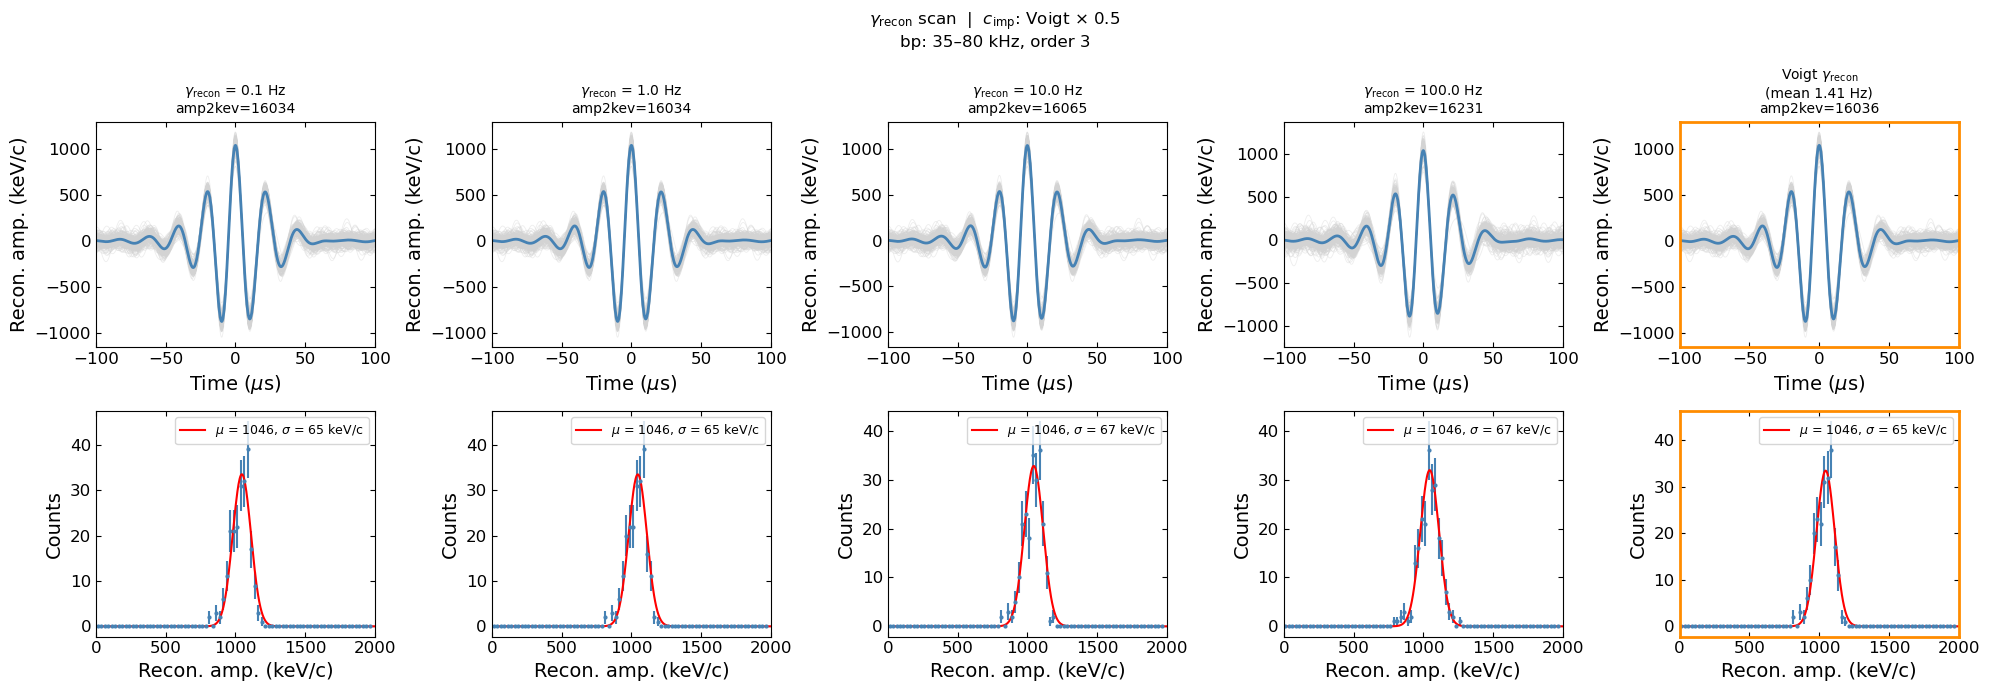

In [20]:
# ── Parameters ────────────────────────────────────────────────────────────
bandpass_lb   = 35000
bandpass_ub   = 80000
lowpass_order = 3

# c_imp scaling = 1/2
fig, axes = run_gamma_scan(_preprocessed, gamma_scan_hz, c_imp_scaling=1/2,
                           bandpass_lb=bandpass_lb, bandpass_ub=bandpass_ub, lowpass_order=lowpass_order,
                           **_kw_base)
plt.show()

Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
γ_recon = 0.1 Hz → 220 pulses, amp2kev = 14184
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
γ_recon = 1.0 Hz → 220 pulses, amp2kev = 14189
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
γ_recon = 10.0 Hz → 220 pulses, amp2kev = 14210
Skipping pulse too close to the beginning of the

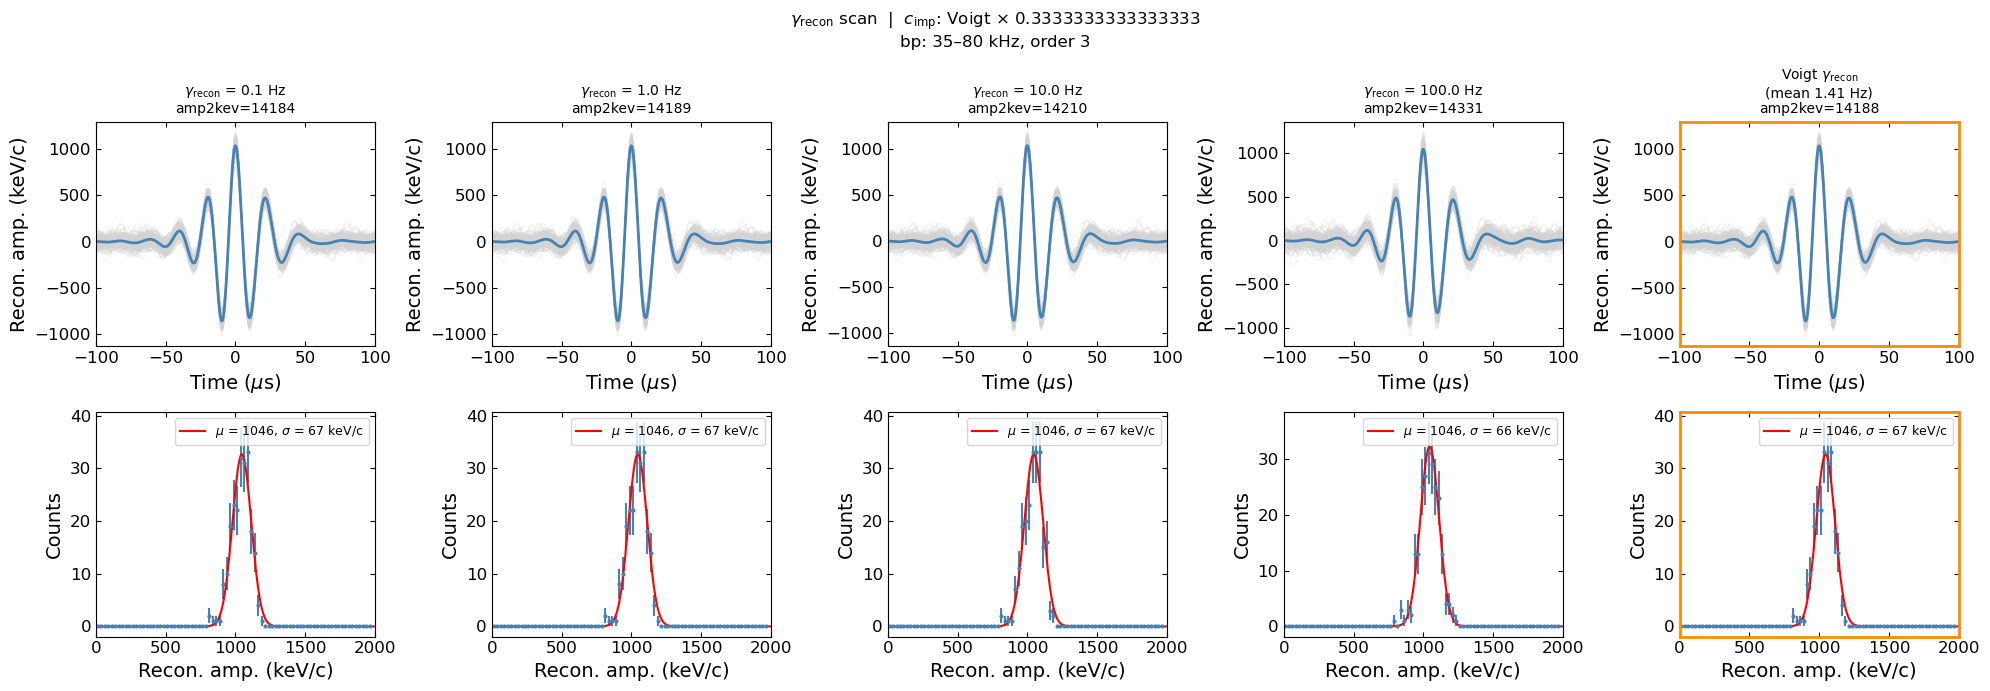

In [21]:
# ── Parameters ────────────────────────────────────────────────────────────
bandpass_lb   = 35000
bandpass_ub   = 80000
lowpass_order = 3

# c_imp scaling = 1/3
fig, axes = run_gamma_scan(_preprocessed, gamma_scan_hz, c_imp_scaling=1/3,
                           bandpass_lb=bandpass_lb, bandpass_ub=bandpass_ub, lowpass_order=lowpass_order,
                           **_kw_base)
plt.show()

Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
γ_recon = 0.1 Hz → 220 pulses, amp2kev = 13098
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
γ_recon = 1.0 Hz → 220 pulses, amp2kev = 13098
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
γ_recon = 10.0 Hz → 220 pulses, amp2kev = 13104
Skipping pulse too close to the beginning of the

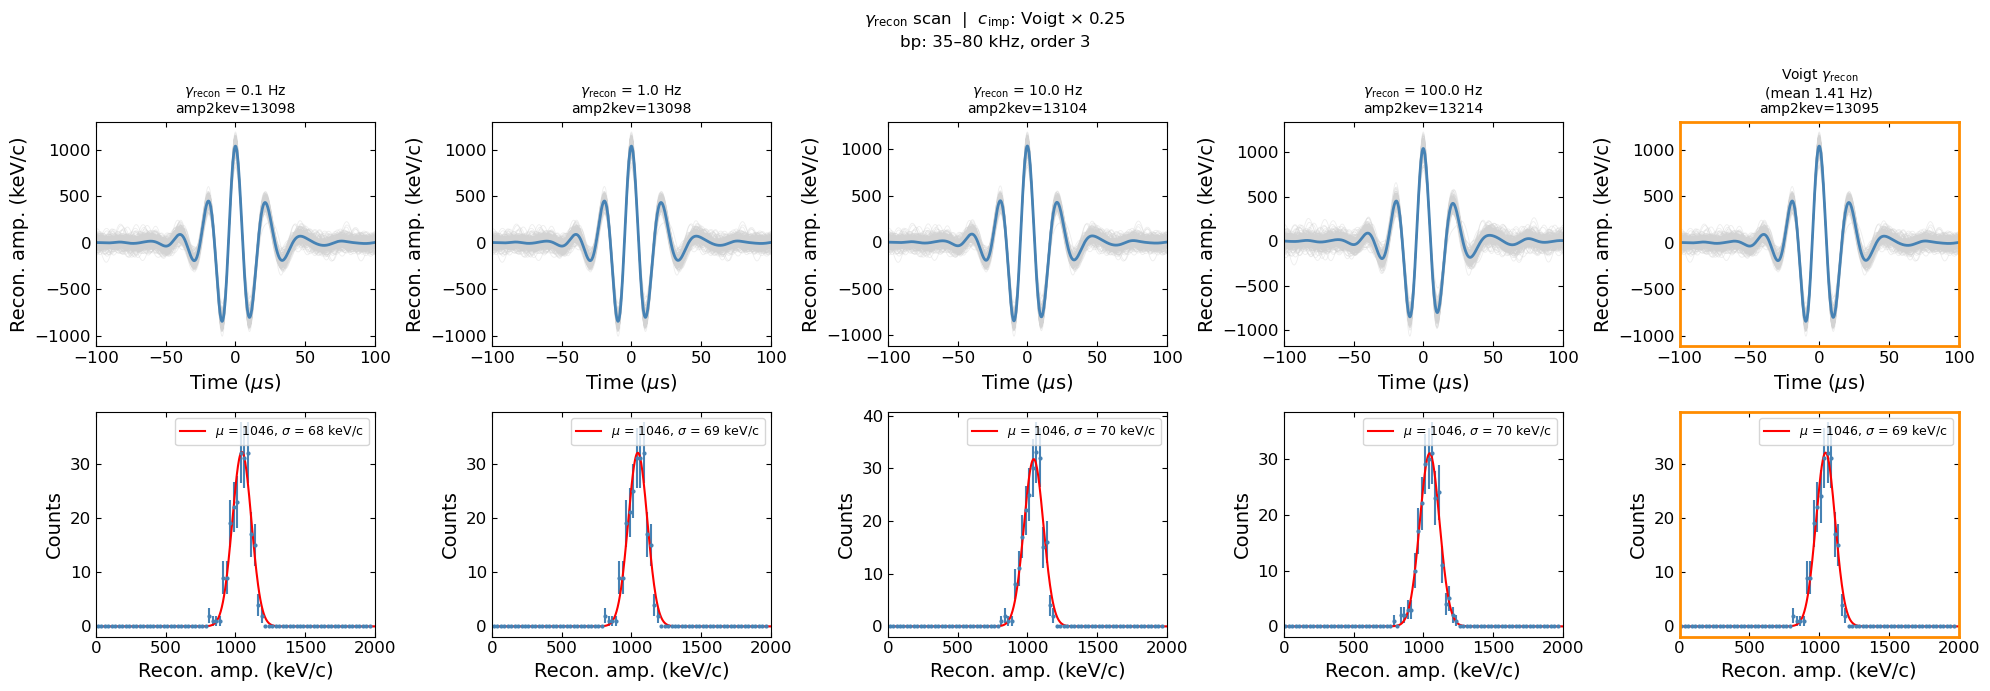

In [22]:
# ── Parameters ────────────────────────────────────────────────────────────
bandpass_lb   = 35000
bandpass_ub   = 80000
lowpass_order = 3

# c_imp scaling = 1/4
fig, axes = run_gamma_scan(_preprocessed, gamma_scan_hz, c_imp_scaling=1/4,
                           bandpass_lb=bandpass_lb, bandpass_ub=bandpass_ub, lowpass_order=lowpass_order,
                           **_kw_base)
plt.show()

Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
γ_recon = 0.1 Hz → 220 pulses, amp2kev = 12351
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
γ_recon = 1.0 Hz → 220 pulses, amp2kev = 12347
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
γ_recon = 10.0 Hz → 220 pulses, amp2kev = 12363
Skipping pulse too close to the beginning of the

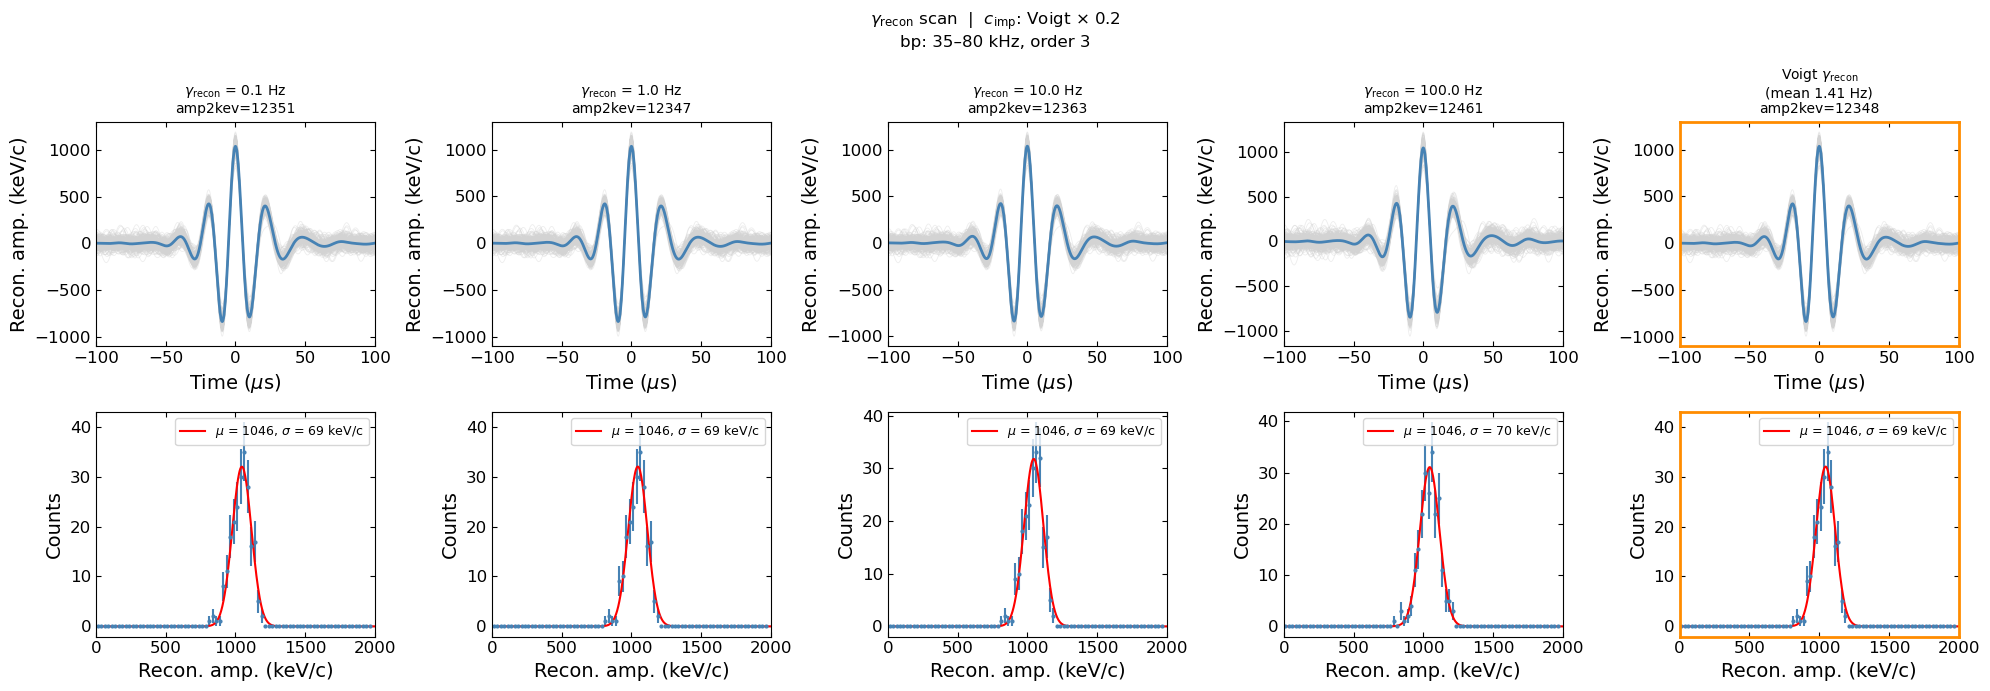

In [23]:
# ── Parameters ────────────────────────────────────────────────────────────
bandpass_lb   = 35000
bandpass_ub   = 80000
lowpass_order = 3

# c_imp scaling = 1/5
fig, axes = run_gamma_scan(_preprocessed, gamma_scan_hz, c_imp_scaling=1/5,
                           bandpass_lb=bandpass_lb, bandpass_ub=bandpass_ub, lowpass_order=lowpass_order,
                           **_kw_base)
plt.show()

Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
γ_recon = 0.1 Hz → 220 pulses, amp2kev = 10530
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
γ_recon = 1.0 Hz → 220 pulses, amp2kev = 10532
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
γ_recon = 10.0 Hz → 220 pulses, amp2kev = 10538
Skipping pulse too close to the beginning of the

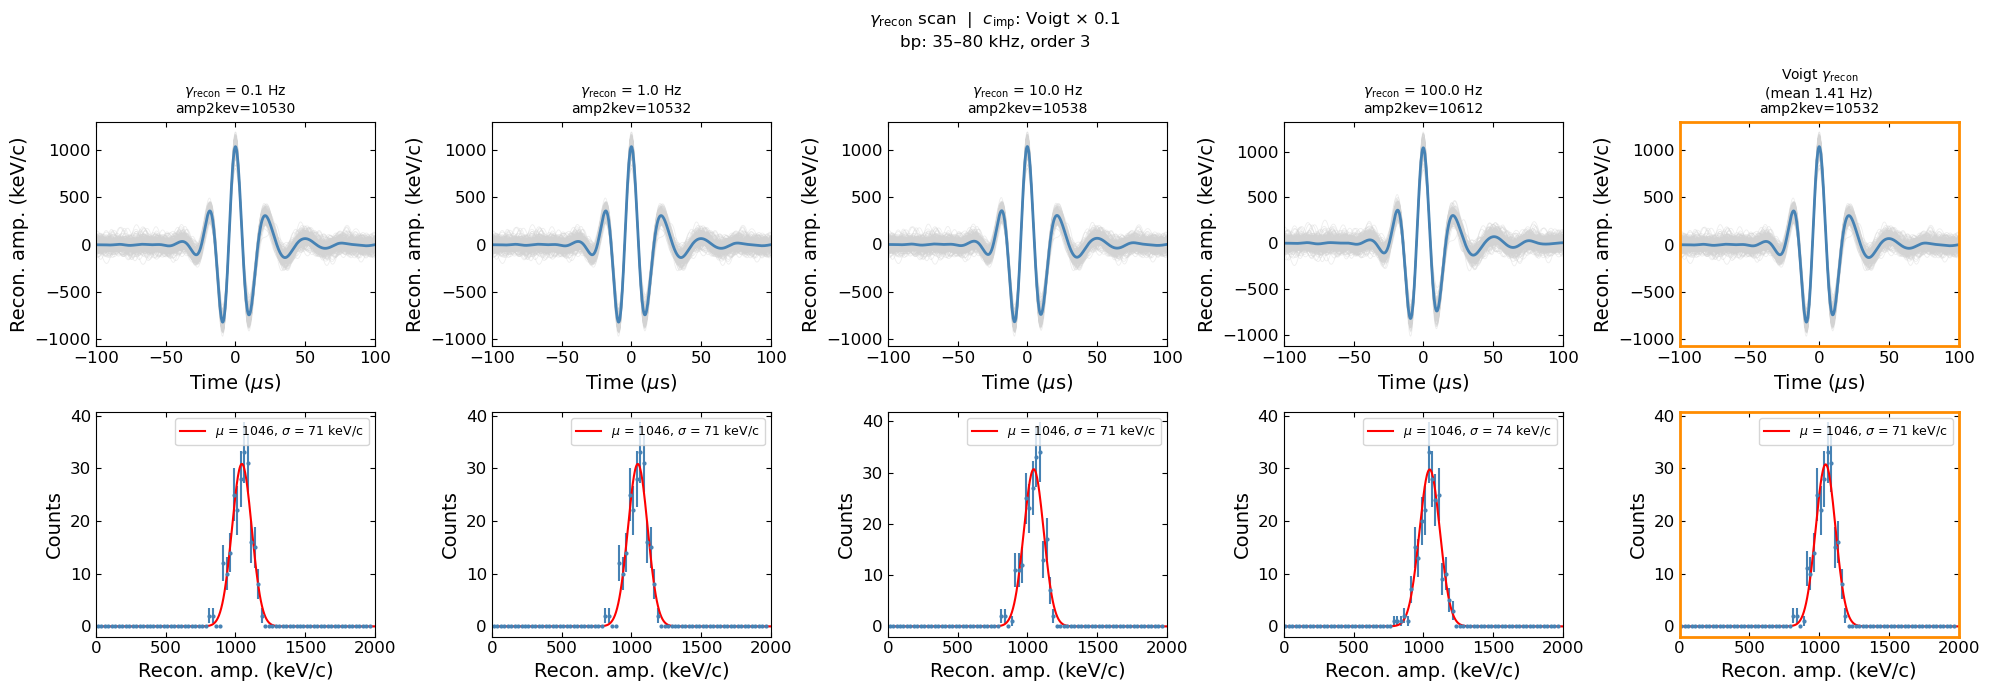

In [24]:
# ── Parameters ────────────────────────────────────────────────────────────
bandpass_lb   = 35000
bandpass_ub   = 80000
lowpass_order = 3

# c_imp scaling = 1/10
fig, axes = run_gamma_scan(_preprocessed, gamma_scan_hz, c_imp_scaling=1/10,
                           bandpass_lb=bandpass_lb, bandpass_ub=bandpass_ub, lowpass_order=lowpass_order,
                           **_kw_base)
plt.show()